# 01 — Introduction to Matplotlib

Matplotlib is the foundational plotting library in the Python scientific ecosystem. In the official documentation, it is described as a library for making **2D plots of arrays in Python**. That description is accurate, but in practice the library is broader than the phrase first suggests: Matplotlib can draw line charts, scatterplots, bar charts, histograms, images, heatmaps, annotations, legends, and multi-panel figures, and it can render them in notebooks, interactive windows, and exported files such as PNG, PDF, and SVG.

This is why Matplotlib deserves a serious introduction. Even when you later use higher-level tools such as Seaborn or pandas plotting, many of those tools still rely on Matplotlib underneath. If you understand Matplotlib well, you are not just learning one package. You are learning the basic grammar of figure construction that much of the Python visualization stack builds on.

## What Matplotlib is

At a high level, Matplotlib builds figures by combining several layers:

- a **figure**, which is the full canvas or page
- one or more **axes**, which are the actual plotting panels
- **artists**, which are the visible things that get drawn: lines, points, text, bars, images, legends, and so on
- a **backend**, which is the rendering system that shows the figure in a notebook, an application window, or an exported file

This layered design is one reason Matplotlib can be used in many contexts. The same plotting code can often be shown:

- inline in a Jupyter notebook
- in a desktop window during interactive work
- in a saved file for slides, reports, or papers

That flexibility is a major strength, but it also means the library can feel large and slightly intimidating at first. The best way to make it manageable is to learn its structure before worrying about advanced chart design.

## A short history

Matplotlib was created by **John D. Hunter**, the original author of the project. In the official project history, Hunter explains that the library grew out of a practical need: he wanted high-quality plotting in Python while working on scientific applications that had outgrown what he could comfortably do in MATLAB.

That historical point explains several things students still notice today:

- Matplotlib has some syntax that feels familiar to people who have seen MATLAB-style plotting
- at the same time, it also supports a more explicit, Pythonic, object-oriented workflow
- the library was designed not only for quick exploratory figures, but also for publication-quality output and for embedding plots inside larger applications

So Matplotlib did not begin as a toy plotting package. It was designed from the start for serious analytical and scientific work.

## The design philosophy

The official project materials also make Matplotlib's philosophy clear: **simple plots should be easy to create, but harder plots should remain possible**.

That is why Matplotlib has two faces that students sometimes find contradictory at first:

- one face is short and convenient: a few commands can already make a plot
- the other face is explicit and structured: figures, axes, artists, layout, and saving can all be controlled deliberately

Those two faces are not in conflict. They are part of the same design. Matplotlib tries to let beginners get started quickly while still giving advanced users precise control.

This notebook focuses on that structure. We are **not** starting with a catalog of chart types. We are starting with the architecture that makes later plotting decisions easier to understand.

## How Matplotlib fits with pandas and Seaborn

It is useful to understand Matplotlib early because many other Python visualization tools build on it.

- `pandas.DataFrame.plot(...)` usually creates a Matplotlib figure and returns Matplotlib axes
- Seaborn typically draws onto a Matplotlib `Axes`, even when the syntax looks different
- many notebook, reporting, and export workflows eventually rely on Matplotlib's figure model

So when you learn how to create `fig` and `ax`, how to label an axes, or how to save a figure, that knowledge transfers. The surface syntax may change, but the underlying figure logic often stays the same.

**Prerequisites**

This notebook assumes that you already know:

- basic Python syntax
- how to call functions and work with objects
- basic NumPy arrays and pandas DataFrames

**Learning goals**

After working through this notebook you will be able to:

1. explain the relationship between `Figure`, `Axes`, `Axis`, and `Artist`
2. distinguish the interactive `pyplot` workflow from the explicit object-oriented workflow
3. control figure size, DPI, and export format deliberately
4. create regular subplot grids with `plt.subplots()` and shared axes
5. understand where basic layout decisions belong before moving on to styling or chart selection

**Roadmap**

1. understand the object model
2. compare `pyplot` with the object-oriented interface
3. learn how figure size and DPI work
4. treat a single `Axes` as the basic unit of plotting
5. build regular subplot grids
6. use layout engines at a high level
7. save figures correctly

**Official documentation threads behind this notebook**

- [Introduction to Figures](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Introduction to Axes](https://matplotlib.org/stable/users/explain/axes/index.html)
- [Introduction to Artists](https://matplotlib.org/stable/users/explain/artists/artist_intro.html)
- [Project history](https://matplotlib.org/stable/project/history.html) and [mission](https://matplotlib.org/stable/project/mission.html)

> **Notebook series** · **01 Introduction to Matplotlib** · [02 Customizing Appearance](02-customizing_appearance.ipynb) · [03 Charts with Matplotlib](03-charts-matplotlib.ipynb) · [04 Advanced Subplotting](04-advanced_subplotting.ipynb)


In [1]:
import sys
from pathlib import Path

tutorials_dir = Path.cwd().resolve().parent
if str(tutorials_dir) not in sys.path:
    sys.path.insert(0, str(tutorials_dir))

from dataviz_utils import *

set_seeds()
setup_matplotlib()
FIG = make_figure_size_scale()

pen = load_penguins()
gap = load_gapminder()
continent_year = (
    gap.groupby(['continent', 'year'], as_index=False)['lifeExp']
       .mean()
)

print('penguins:', pen.shape, '| gapminder:', gap.shape)


penguins: (333, 7) | gapminder: (1704, 8)


This notebook is about **how Matplotlib works as a plotting system**.

It is not yet about choosing between chart families, advanced styling, or complex composition.
Those come later. The goal here is to make the rest of the sequence easier.

We use two small, familiar datasets as convenient examples:

- `penguins` — clean numeric variables, good for scatterplots
- `gapminder` — compact time series, good for subplot examples

The stronger questions — *which chart is appropriate? how should a figure be styled professionally?* — belong in later notebooks.
Here we stay one level lower: **what objects does Matplotlib create, how do they relate, and where do different decisions belong?**


## 1 — The object model

A common beginner mistake is to think of Matplotlib as only a library of plotting functions such as `plot()` and `scatter()`. That view is understandable, because those functions are often the first thing people see. But it is incomplete. Matplotlib is really a hierarchy of objects that work together.

The official documentation repeatedly emphasizes this object structure because it is the key to understanding how figures are built and why different methods belong in different places.

The four names that matter most at the beginning are:

| Object | What it is | Why it matters |
|---|---|---|
| `Figure` | the whole canvas or output page | figure-level size, layout, super-titles, and saving happen here |
| `Axes` | one plotting panel inside the figure | most plotting commands are methods on `Axes` |
| `Axis` | one scale inside an `Axes` | ticks, tick labels, locators, formatters, and scales live here |
| `Artist` | any visible thing Matplotlib draws | lines, text, points, patches, legends, and images are all artists |

Two details are worth slowing down for:

1. `Axes` and `Axis` are **not** the same thing. The naming is historical and initially confusing. An `Axes` is the whole plotting panel; an `Axis` is only the x- or y-scale inside that panel.
2. Most of the time, your day-to-day plotting work happens on the `Axes` object. That is why so much Matplotlib code starts with `fig, ax = plt.subplots(...)`.

A practical way to think about the hierarchy is:

- the `Figure` answers *how big is the full page and how many panels does it contain?*
- the `Axes` answers *what data is shown in this panel and how is it labeled?*
- the `Axis` answers *how is one direction scaled and ticked?*
- the `Artists` answer *what visible marks and text are actually drawn?*

![Anatomy of a Matplotlib figure](images/anatomy.png)

This mental model matters because it tells you **where to look** when something goes wrong. If the whole canvas is too small, that is a figure-level problem. If labels or limits are wrong, that is usually an axes-level problem. If a tick format looks wrong, that is an axis-level problem.

### The four core objects in more detail

The official documentation is especially useful here because it shows not only the names of the objects, but also the kinds of methods that belong to each one.

#### `Figure`

A `Figure` is the outer container. It represents the whole page or canvas.

Typical figure-level tasks include:

- creating one or more axes with `subplots()`, `add_subplot()`, or `add_axes()`
- setting figure-wide labels or titles with `suptitle()`, `supxlabel()`, and `supylabel()`
- adding a figure-level legend with `legend()`
- adding a colorbar with `colorbar()`
- saving the final result with `savefig()`

A good rule is: if a decision concerns the **whole page**, it probably belongs to the figure.

#### `Axes`

The Matplotlib documentation describes `Axes` as the gateway to making visualizations. This is the object students should get comfortable with first.

Typical axes-level tasks include:

- drawing data with methods such as `plot()`, `scatter()`, `bar()`, `hist()`, and `imshow()`
- setting labels and titles with `set_xlabel()`, `set_ylabel()`, and `set_title()`
- controlling the view with `set_xlim()`, `set_ylim()`, `set_xscale()`, and `set_yscale()`
- adding explanatory structure with `legend()`, `annotate()`, and `grid()`

A good rule is: if a decision concerns **one panel**, it probably belongs to the axes.

#### `Axis`

Each axes usually contains two `Axis` objects: one for x and one for y. Their job is to define the coordinate system and manage how values are displayed.

Important responsibilities of an `Axis` include:

- placing tick marks
- formatting tick labels
- handling locators and formatters
- applying scales such as linear or logarithmic

At the beginning, students often configure these things indirectly through axes-level methods such as:

- `ax.set_xticks(...)`
- `ax.set_yticks(...)`
- `ax.tick_params(...)`
- `ax.set_xscale('log')`

Later, when finer control is needed, you can access the axis objects directly through `ax.xaxis` and `ax.yaxis`.

#### `Artist`

In the official artist tutorial, almost everything you interact with on a Matplotlib plot is called an **Artist**.

Examples:

- `ax.plot(...)` creates `Line2D` artists
- `ax.bar(...)` creates `Rectangle` artists
- `ax.imshow(...)` creates an `AxesImage`
- `ax.text(...)` creates a `Text` artist
- `ax.legend(...)` creates a `Legend`

This idea is powerful because it explains why created objects can often be modified after the fact. Once you have the artist, you can change properties such as color, linewidth, alpha, text content, or drawing order.

That is one reason Matplotlib supports careful styling and animation: the visible elements are objects, not just one-time drawing commands.

Figure  : Figure
Axes    : Axes
x-Axis  : XAxis
Line2D  : Line2D


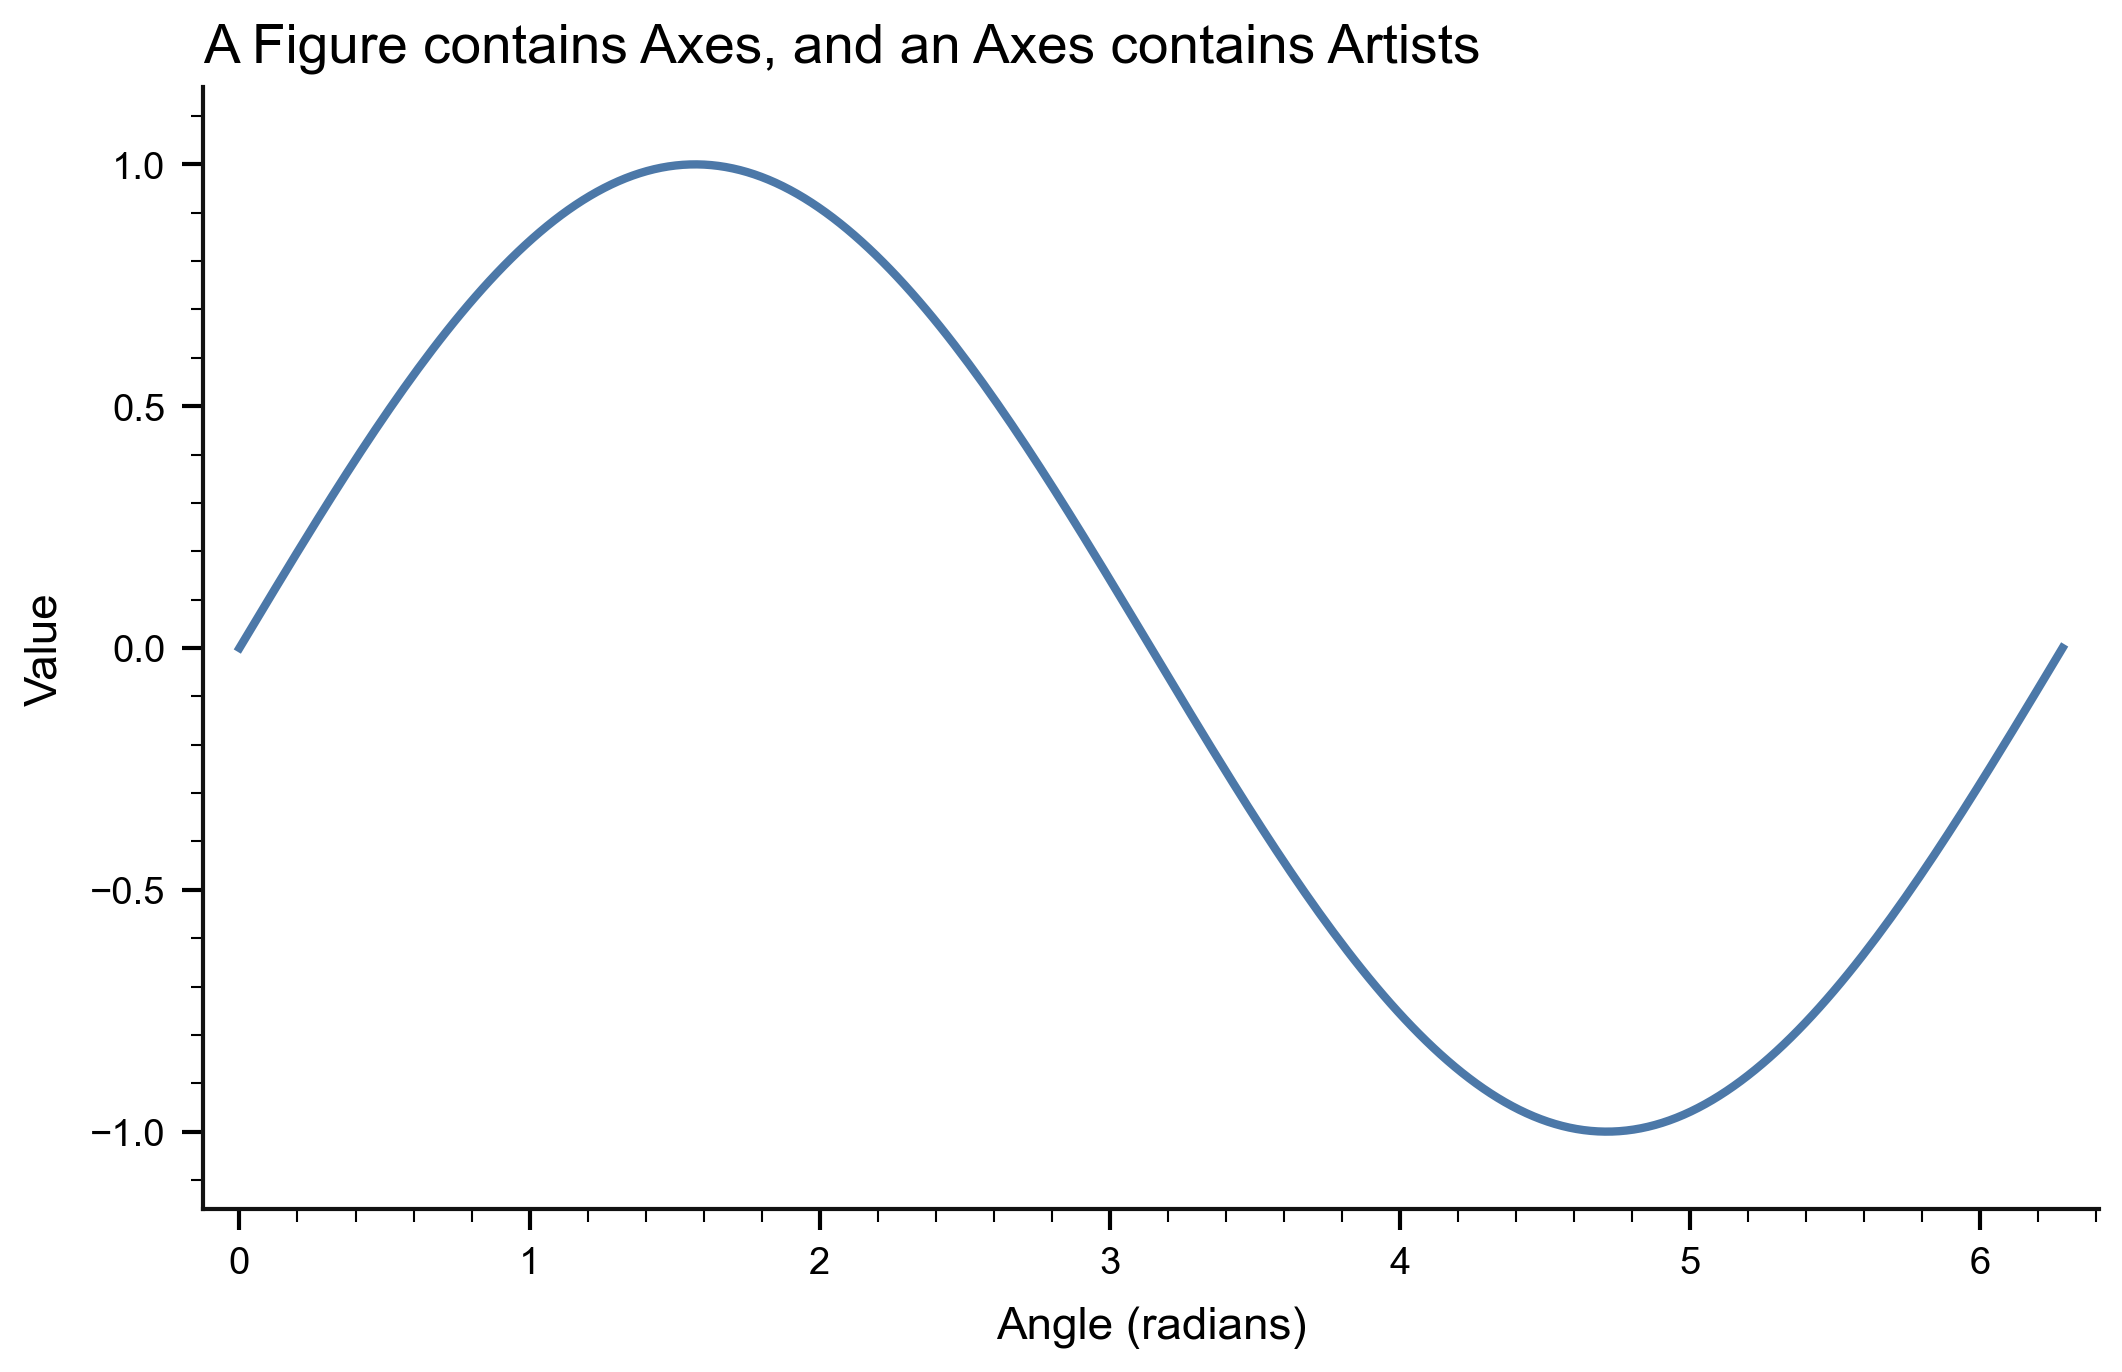

In [2]:
x = np.linspace(0, 2 * np.pi, 256)
fig, ax = plt.subplots(figsize=FIG['standard'])
(line,) = ax.plot(x, np.sin(x), color=DV_PALETTE['blue'])
ax.set_title('A Figure contains Axes, and an Axes contains Artists')
ax.set_xlabel('Angle (radians)')
ax.set_ylabel('Value')
ax.grid(False)
print('Figure  :', type(fig).__name__)
print('Axes    :', type(ax).__name__)
print('x-Axis  :', type(ax.xaxis).__name__)
print('Line2D  :', type(line).__name__)


**What to notice in the output**

The printed types are not there to memorize class names mechanically. They show that one visible chart is assembled from several different objects.

- `fig` is the outer container
- `ax` is the panel we draw into
- `ax.xaxis` is the scale object for the horizontal direction
- the line returned by `ax.plot(...)` is an `Artist`

That is the core of the object model. A figure is not one monolithic thing. It is a set of nested objects with different responsibilities.

### What sits inside an `Axes`?

Students often meet `ax` very early, but they are not always told what it contains. An `Axes` is much more than an empty rectangular box. It manages:

- scales and limits
- tick marks and tick labels
- axis labels and titles
- plotted marks such as lines, points, bars, and images
- text annotations, legends, and patches

In Matplotlib, all of those visible components are artists owned by the axes. You do **not** need to manipulate every artist directly in normal work. But knowing that they exist makes debugging much easier.

For example:

- if a legend overlaps the data, it helps to know that the legend is just another artist inside the axes
- if the tick labels are poorly spaced, that is an axis-management issue inside the axes
- if a plotted line needs to be restyled after creation, the line artist can be retrieved and edited

This is one of the reasons the object-oriented style is so valuable. Once you have a named axes object, you also have a clear entry point into all the visible structure that belongs to that panel.

Some artist types on this Axes:
PathCollection, Rectangle, Spine, Text, XAxis, YAxis
Total artists on the Axes: 11


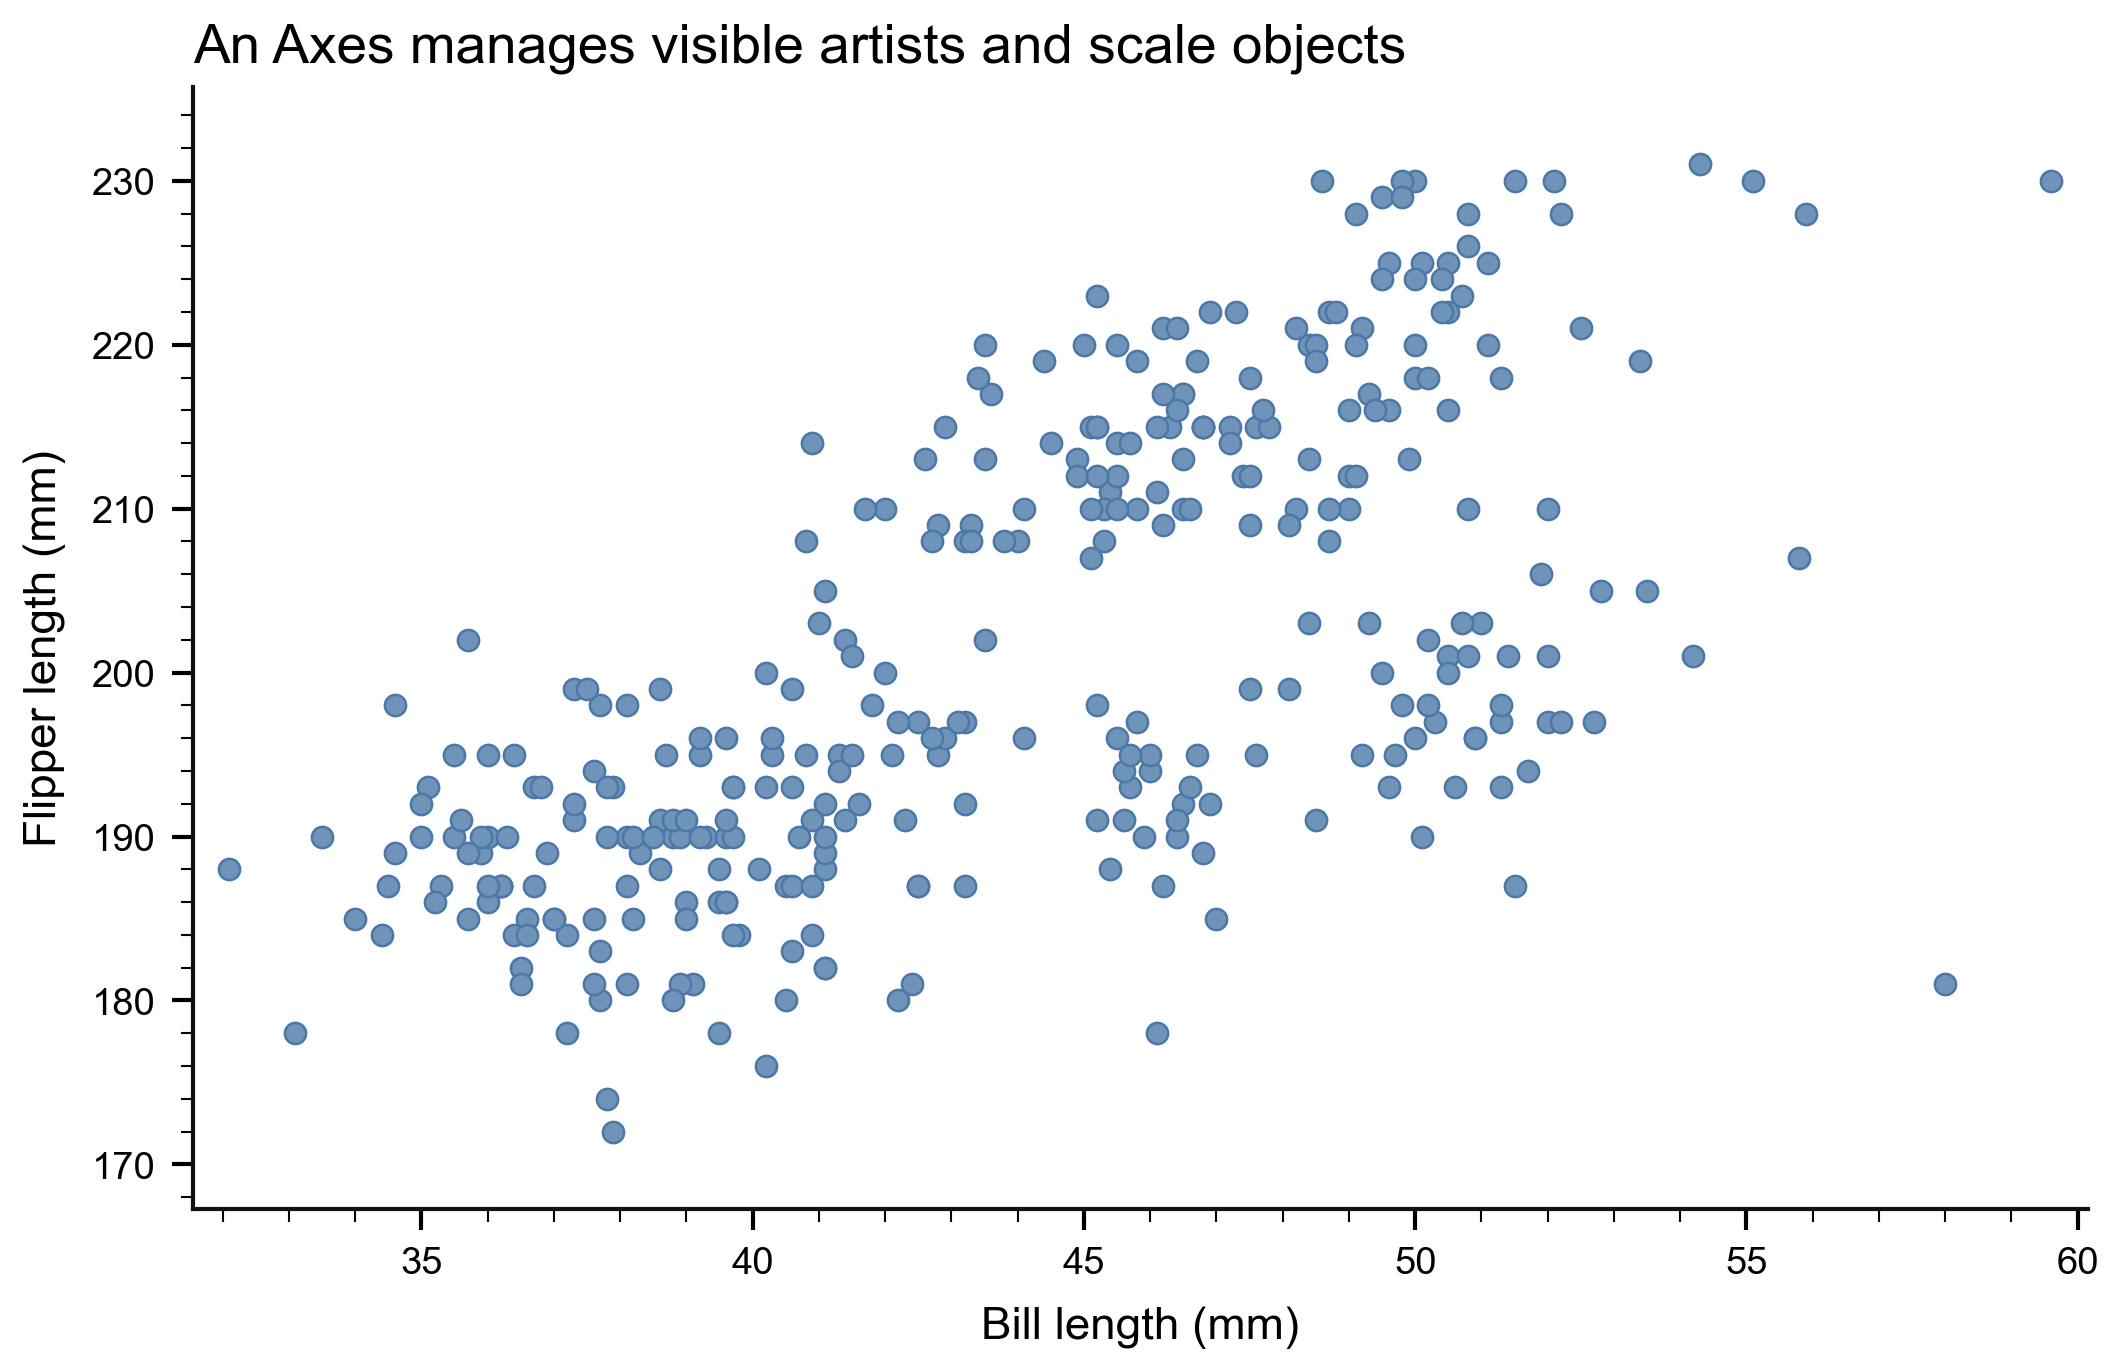

In [3]:
fig, ax = plt.subplots(figsize=FIG['standard'])
ax.scatter(
    pen['bill_length_mm'],
    pen['flipper_length_mm'],
    s=26,
    color=lighten_color(DV_PALETTE['blue'], 0.8),
    edgecolor=DV_PALETTE['blue'],
    linewidth=0.6,
)
ax.set_title('An Axes manages visible artists and scale objects')
ax.set_xlabel('Bill length (mm)')
ax.set_ylabel('Flipper length (mm)')
ax.grid(False)
artist_types = sorted({type(artist).__name__ for artist in ax.get_children()})
print('Some artist types on this Axes:')
print(', '.join(artist_types[:12]))
print('Total artists on the Axes:', len(ax.get_children()))


**Why inspect the children of an `Axes`?**

The list of artist types is intentionally a bit messy. That is the point. A real plot contains many moving parts: text, spines, lines, tick objects, and more. You are not expected to memorize the full list. The important lesson is that Matplotlib is inspectable.

When a plot does something unexpected, you can often ask the axes what it contains and reason from there. That is a much more productive mindset than treating plotting libraries as black boxes.

## 2 — `pyplot` vs the object-oriented workflow

Matplotlib offers two related ways of working.

### The `pyplot` workflow

`matplotlib.pyplot` is a **stateful interface**. "Stateful" means that the module remembers a *current figure* and a *current axes*. When you call `plt.plot(...)`, Matplotlib does not need you to say where the line should go; it draws on the current axes.

This is convenient, especially in a notebook, because it lets you type short commands quickly.

### The object-oriented workflow

The object-oriented workflow is explicit. You first create objects such as `fig` and `ax`, and then you call methods on those objects:

- `ax.plot(...)`
- `ax.scatter(...)`
- `ax.set_title(...)`

This is longer, but it is also safer because the target panel is always explicit.

### Why notebooks make the distinction important

An interactive notebook session keeps state alive from one cell to the next. That is useful, but it also means that the "current axes" can change without you noticing if you create another subplot or figure. As soon as a figure has more than one panel, relying purely on implicit state becomes harder to read and easier to misuse.

A good rule for this course is:

- `pyplot` is fine for quick interactive exploration
- the object-oriented workflow is the default for teaching, reproducibility, and multi-panel figures

ID of left current axes : 13405332624
ID of right current axes: 13405331984
Notice that pyplot changed the target axes for us.


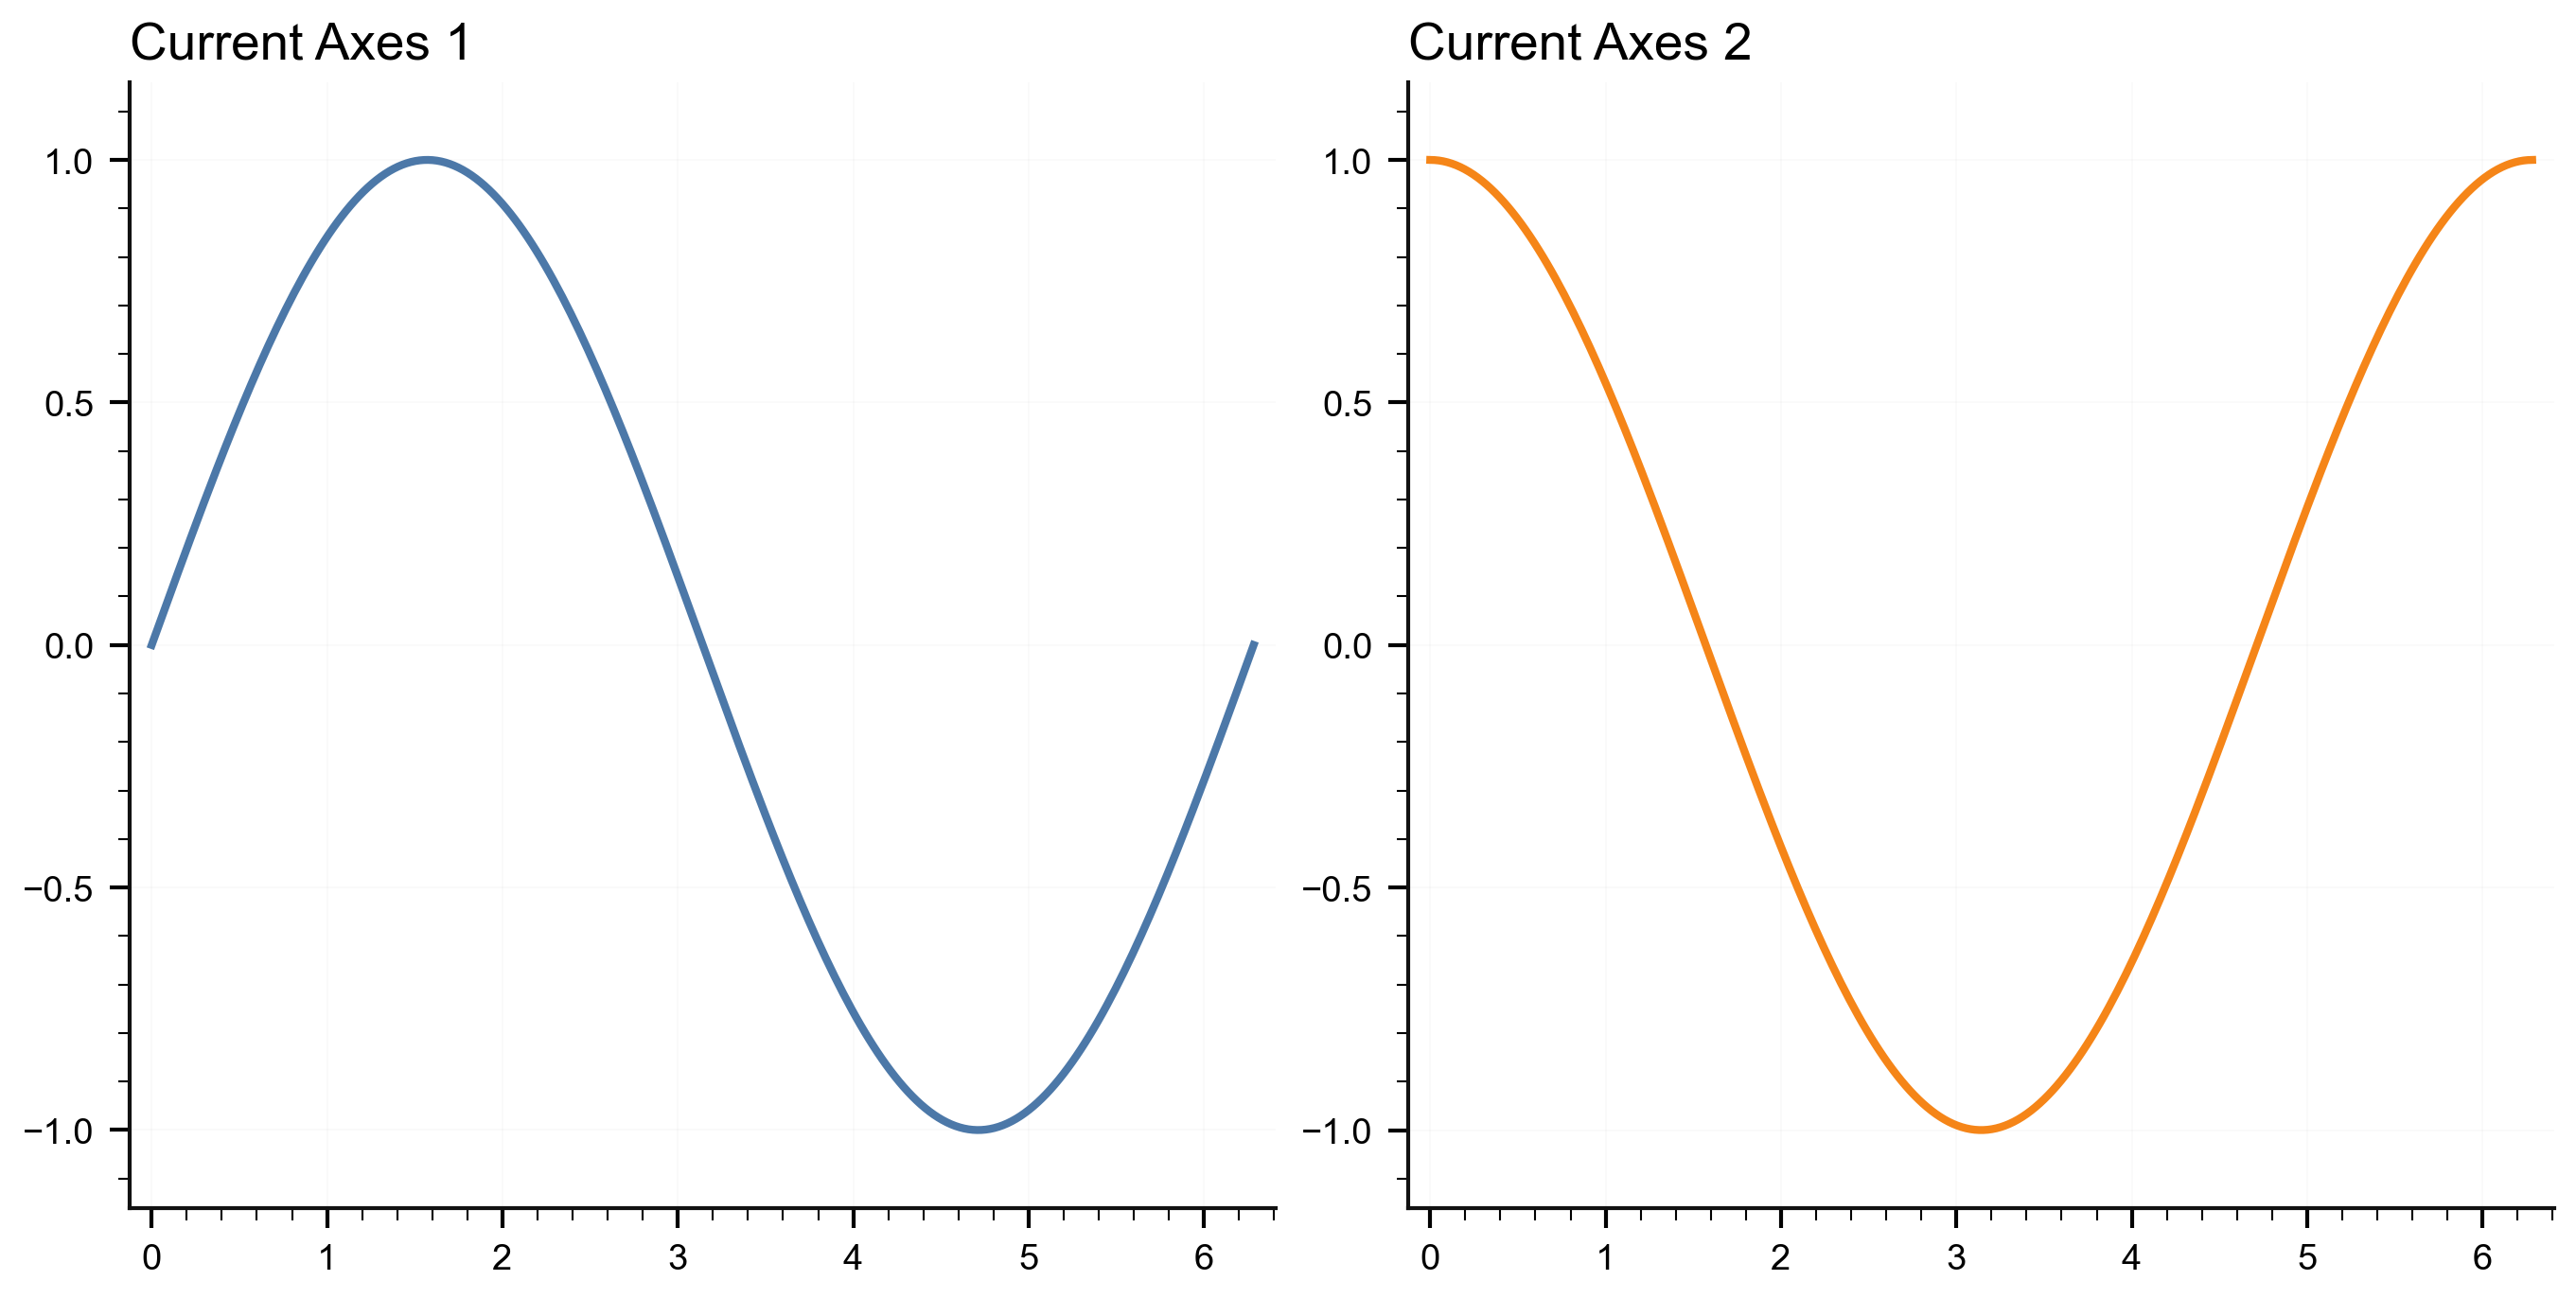

In [4]:
plt.figure(figsize=FIG['wide'])
plt.subplot(1, 2, 1)
plt.plot(x, np.sin(x), color=DV_PALETTE['blue'])
left_id = id(plt.gca())
plt.title('Current Axes 1')

plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x), color=DV_PALETTE['orange'])
right_id = id(plt.gca())
plt.title('Current Axes 2')

print('ID of left current axes :', left_id)
print('ID of right current axes:', right_id)
print('Notice that pyplot changed the target axes for us.')


**What happened in the `pyplot` example?**

The code is short because `pyplot` silently kept track of which subplot was current. When `plt.subplot(1, 2, 2)` was called, the current axes changed. From that moment on, subsequent plotting commands targeted the second panel.

This behavior is not a bug. It is exactly how `pyplot` is designed. The issue is that the logic stays partly implicit. Students can read the code, but they must also remember Matplotlib's internal state machine while reading it.

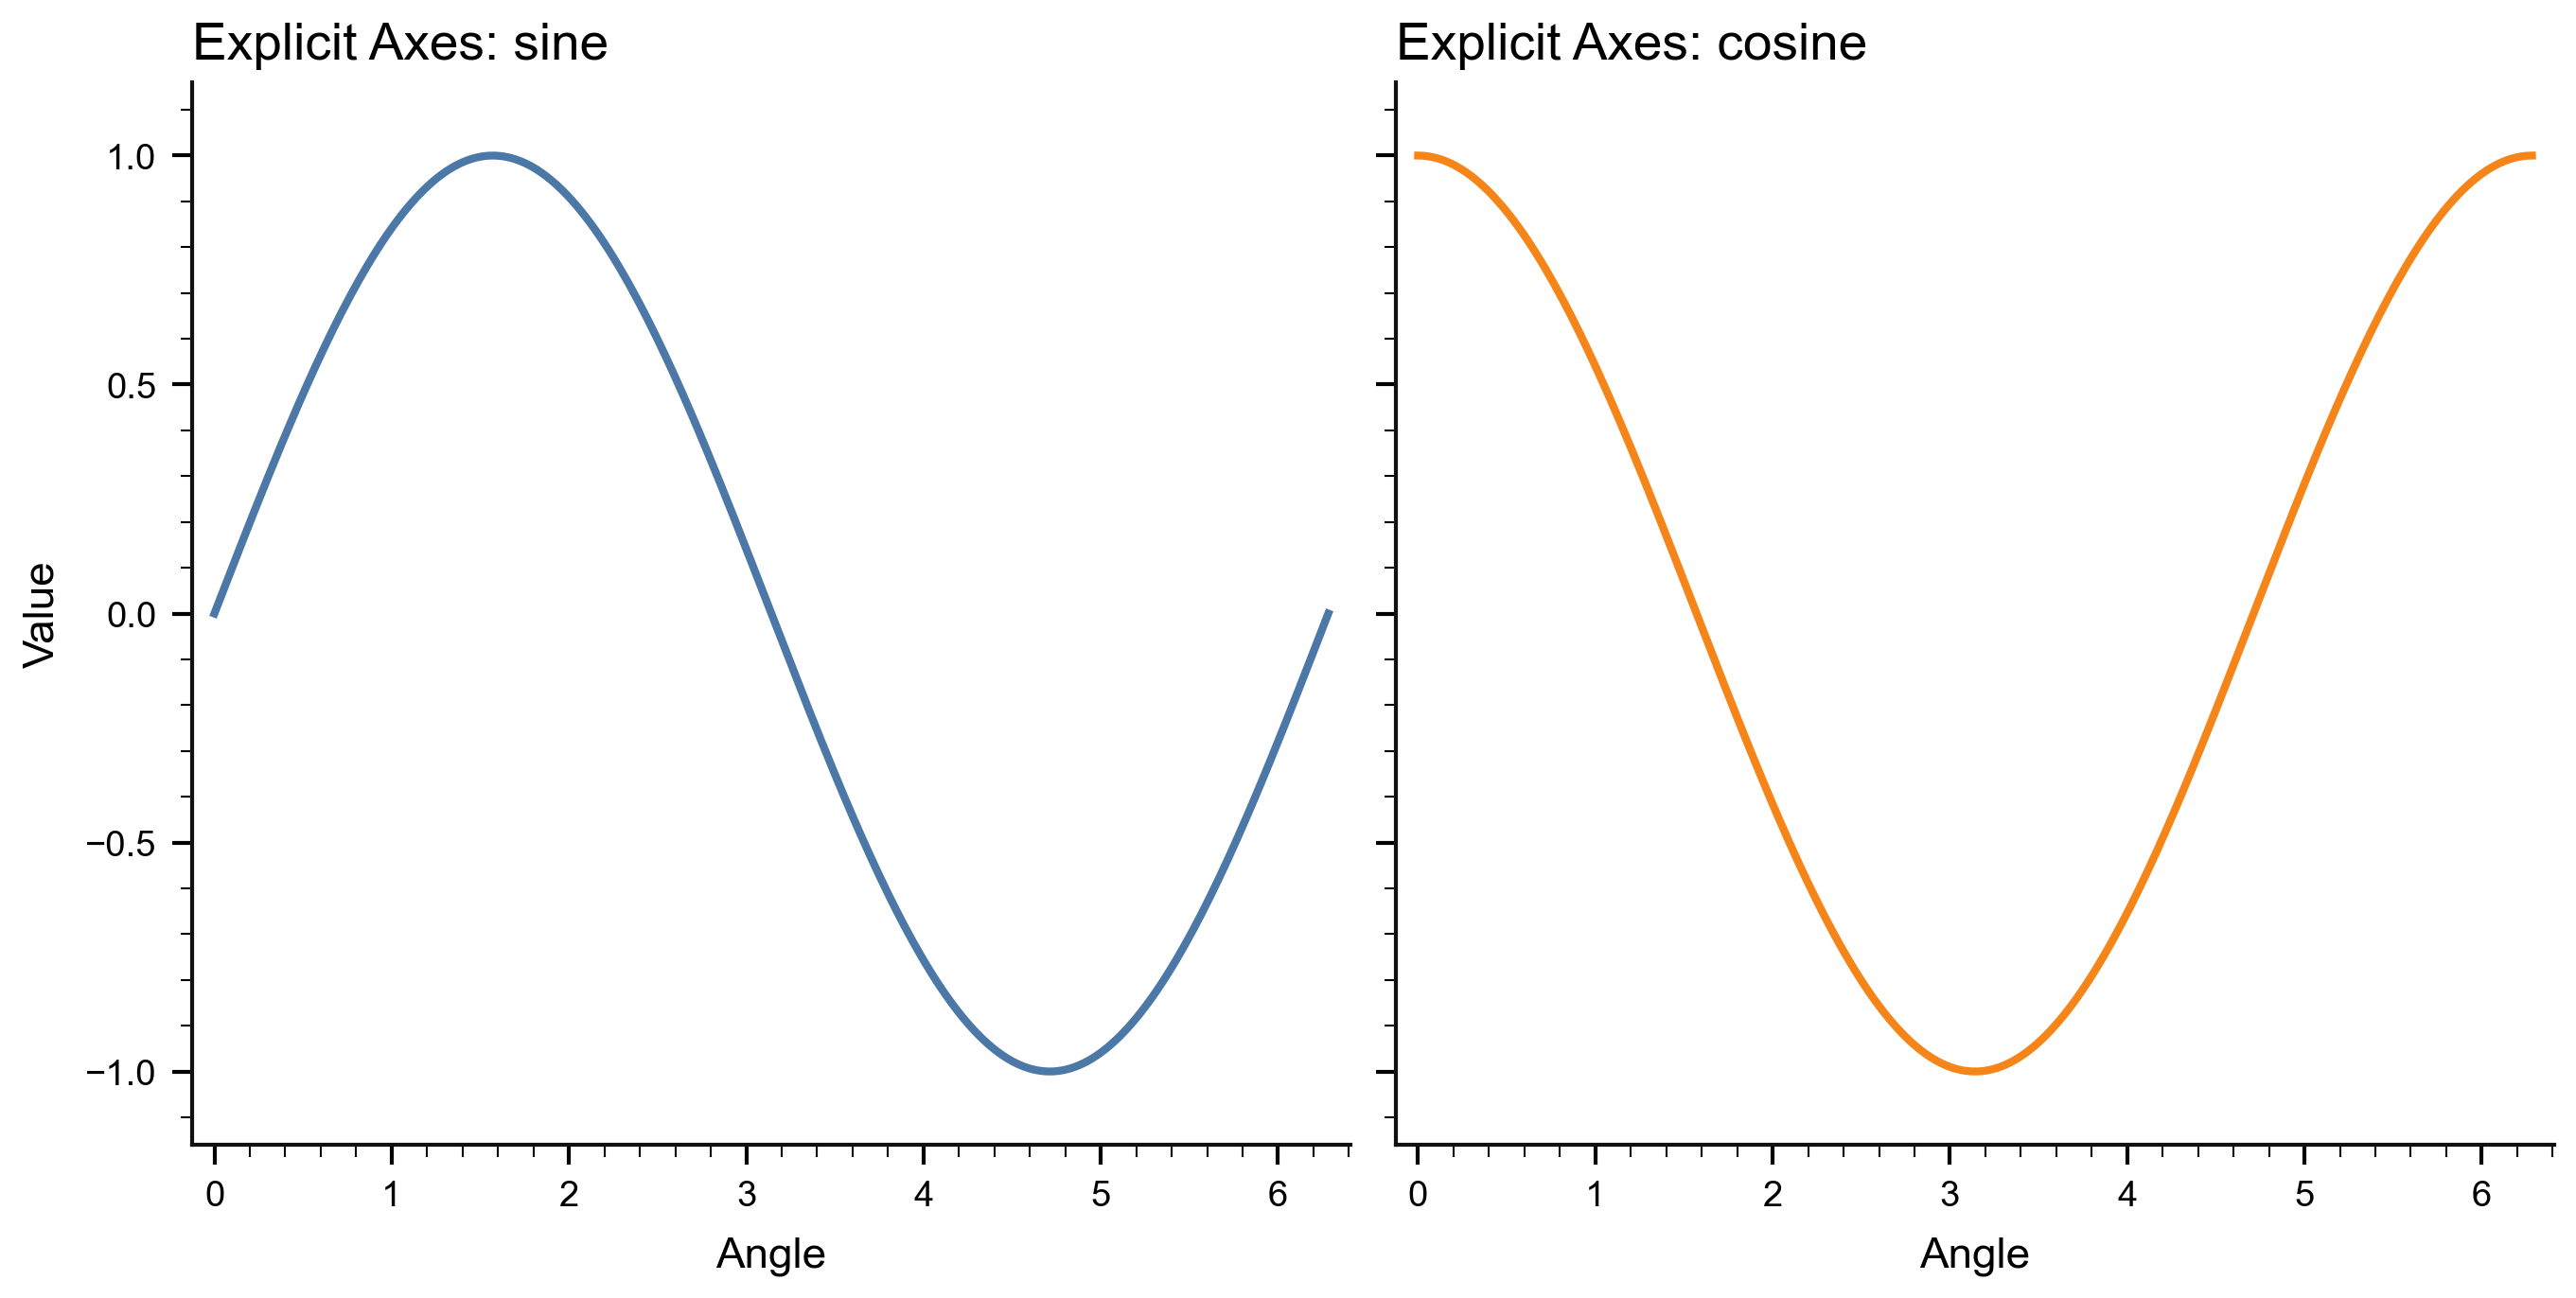

In [5]:
fig, axs = plt.subplots(1, 2, figsize=FIG['wide'], sharey=True)
for ax, func, color, title in [
    (axs[0], np.sin, DV_PALETTE['blue'], 'Explicit Axes: sine'),
    (axs[1], np.cos, DV_PALETTE['orange'], 'Explicit Axes: cosine'),
]:
    ax.plot(x, func(x), color=color)
    ax.set_title(title)
    ax.set_xlabel('Angle')
    ax.set_ylabel('Value' if ax is axs[0] else '')
    ax.grid(False)


**Why the object-oriented style is easier to reason about**

In the second example, every action is attached to a named axes object. There is no ambiguity about where the sine line goes or where the cosine line goes. The code is slightly longer, but the structure is clearer.

That trade-off is worth it. In practice, most non-trivial teaching, analysis, or publication figures are easier to maintain when they use explicit `fig` and `ax` variables.

### Why this matters beyond Matplotlib itself

This object model is not only useful inside pure Matplotlib code.

- When pandas creates a plot, you often still receive a Matplotlib `Axes` back.
- When Seaborn draws a chart, it usually draws onto a Matplotlib `Axes`.
- When you need to refine labels, limits, titles, or export settings, you often return to Matplotlib methods.

So learning these objects is a durable investment. Even if the plotting wrapper changes, the underlying figure model often remains the same.

### Pitfall: figure accumulation in loops

Every call to `plt.figure()` or `plt.subplots()` **pushes a new figure onto a global stack** without removing the previous one.
In a notebook loop this silently leaks memory and eventually triggers:

```
RuntimeWarning: More than 20 figures have been opened.
```

There are three idiomatic fixes.

**Fix 1 — close inside the loop**

```python
for k in data:
    fig, ax = plt.subplots()
    ax.plot(...)
    fig.savefig(f'{k}.png')
    plt.close(fig)       # ← release immediately
```

**Fix 2 — reuse the same figure**

```python
fig, ax = plt.subplots()          # create once, outside the loop
for k in data:
    ax.cla()                       # clear the axes, keep the figure
    ax.plot(...)
    fig.savefig(f'{k}.png')
```

**Fix 3 — use a context manager (scripts)**

```python
import matplotlib
matplotlib.use('Agg')              # non-interactive backend for scripts
for k in data:
    with plt.ioff():               # suppress interactive display
        fig, ax = plt.subplots()
        ax.plot(...)
        fig.savefig(f'{k}.png')
        plt.close(fig)
```

For interactive notebook work, Fix 1 is the clearest default.

A notebook-specific detail is worth noticing here: in Jupyter, `plt.show()` is usually optional because the notebook backend displays figures automatically at the end of a cell.

We keep `plt.show()` in the next example only because the code closes each figure immediately afterward with `plt.close(fig)`. Without the explicit show call, the figure would be closed before the notebook had a chance to display it.

In [6]:
# Demonstration: uncommenting the loop below will open 25 figures
# and trigger the RuntimeWarning.
# plt.rcParams['figure.max_open_warning'] = 5  # lower the threshold for demonstration

n_figures = 5   # safe for demonstration
figs = []
for i in range(n_figures):
    fig, ax = plt.subplots(figsize=(3, 2))  # each iteration pushes a new figure
    ax.plot(x[:64], np.sin(x[:64] + i * 0.5), color=CATEGORICAL_PALETTE[i % len(CATEGORICAL_PALETTE)])
    ax.set_title(f'Figure {i + 1} (no close)')
    ax.grid(False)
    figs.append(fig)

print(f'Figures open now: {len(plt.get_fignums())}')
print('Fix: call plt.close(fig) inside the loop, or plt.close("all") to close all at once.')
plt.close('all')   # clean up for the notebook


Figures open now: 5
Fix: call plt.close(fig) inside the loop, or plt.close("all") to close all at once.


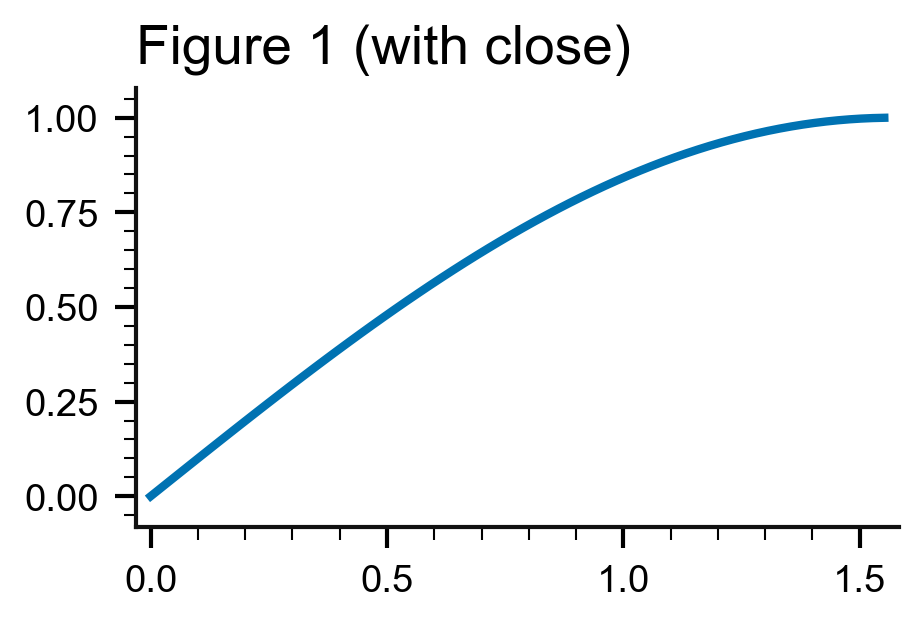

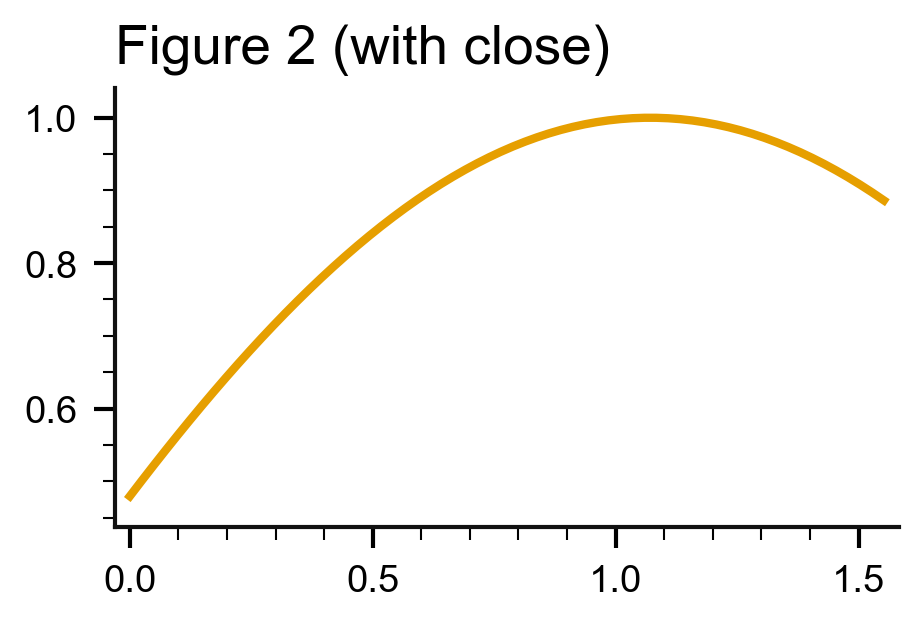

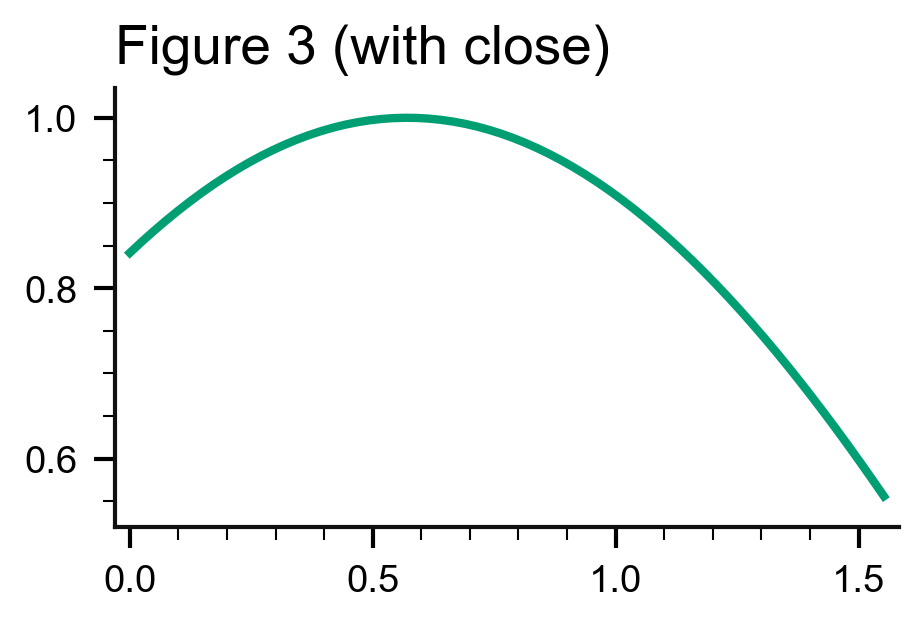

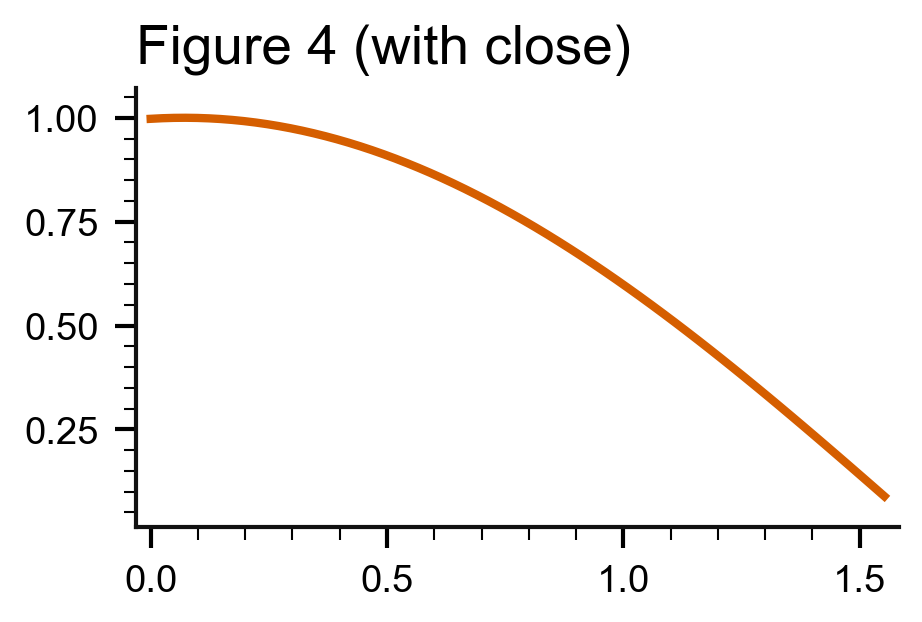

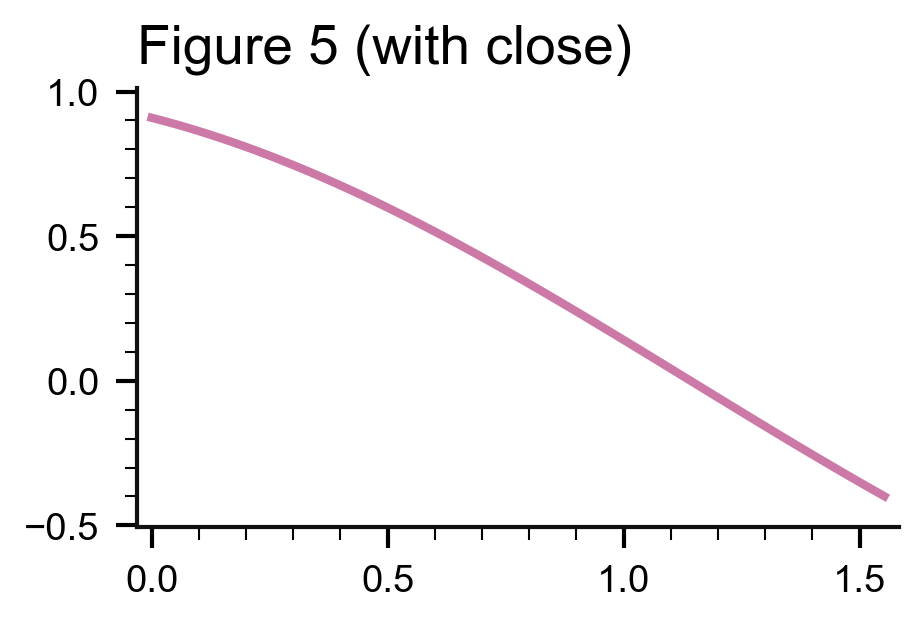

Figures open after loop: 0


In [7]:
# Correct pattern: close each figure immediately after saving / showing
for i in range(n_figures):
    fig, ax = plt.subplots(figsize=(3, 2))
    ax.plot(x[:64], np.sin(x[:64] + i * 0.5), color=CATEGORICAL_PALETTE[i % len(CATEGORICAL_PALETTE)])
    ax.set_title(f'Figure {i + 1} (with close)')
    ax.grid(False)
    plt.show()
    plt.close(fig)   # ← this is all it takes

print(f'Figures open after loop: {len(plt.get_fignums())}')  # should be 0


## 3 — Figure size and DPI

When a figure looks too small, too blurry, or too crowded, two ideas are often being confused:

- **figure size**: how much logical drawing space the figure has
- **DPI**: how densely raster pixels are packed into that space

### Figure size

Matplotlib measures figure size in **inches**. That may feel unusual in a digital environment, but it is useful because it makes figure dimensions device-independent. A figure that is `5 × 3` inches is conceptually the same figure whether you view it on one laptop, another laptop, or send it to a printer.

### DPI

DPI means **dots per inch**. For raster formats such as PNG, DPI controls how many pixels are used to represent the figure. Higher DPI means more pixels and usually sharper raster output.

### How they combine

For raster graphics:

`pixels = inches × dpi`

So a figure that is 5 inches wide at 150 DPI becomes 750 pixels wide.

### A crucial distinction

DPI matters for raster exports such as PNG. It does **not** play the same role for vector formats such as PDF or SVG, where the geometry is stored as shapes and text rather than a fixed pixel grid.

Figure size: 5.0 × 3.0 inches
DPI: 150
Raster size: 750 × 450 pixels


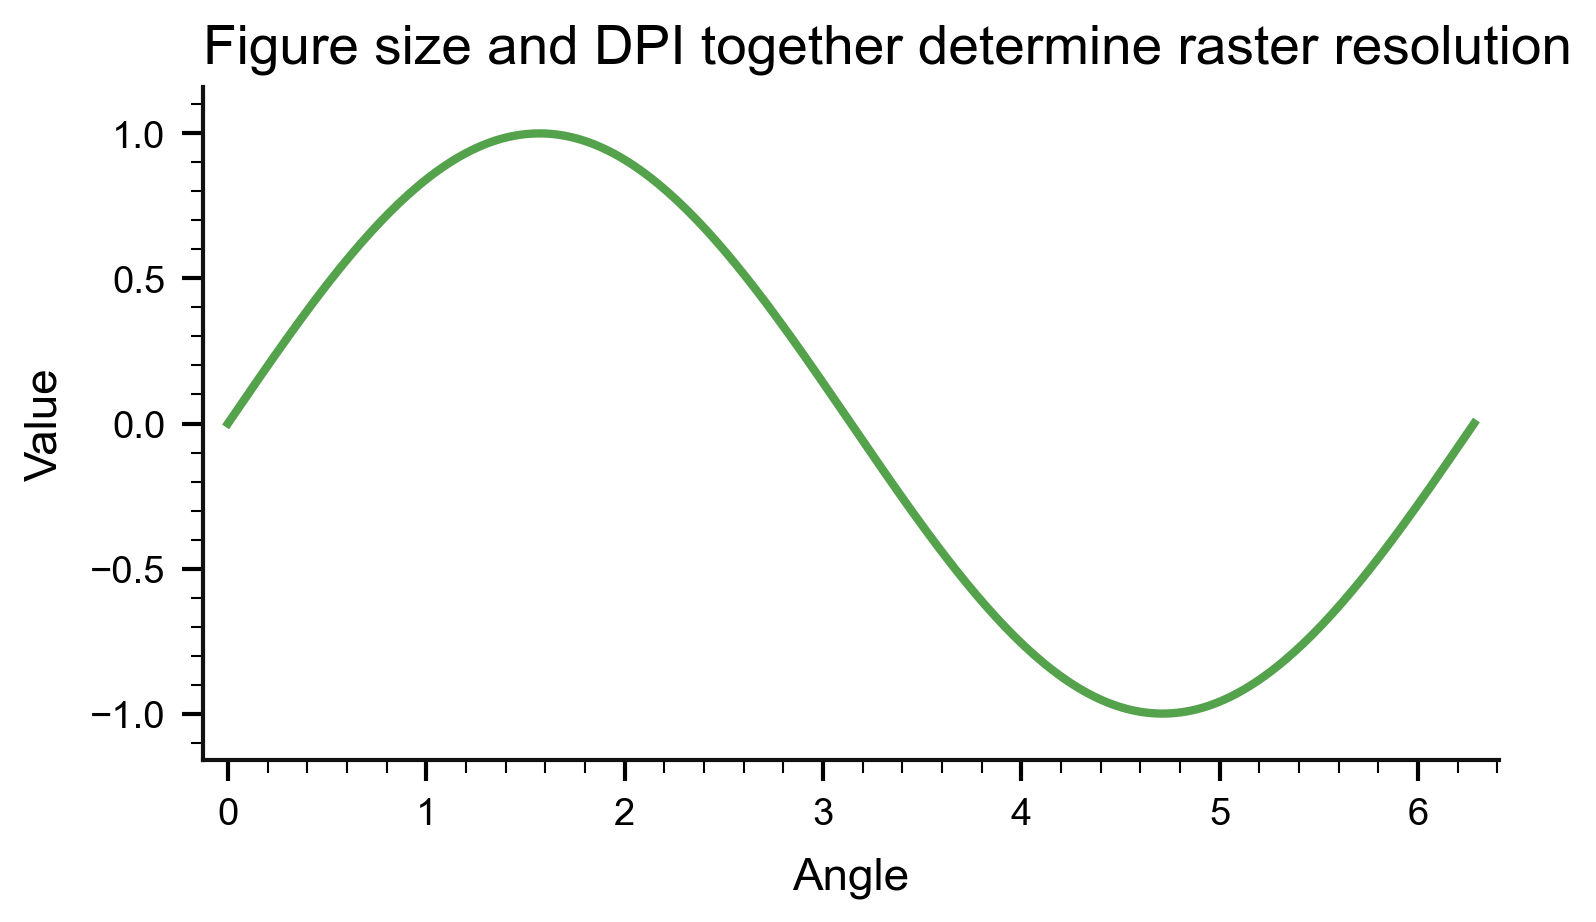

In [8]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
ax.plot(x, np.sin(x), color=DV_PALETTE['green'])
ax.set_title('Figure size and DPI together determine raster resolution')
ax.set_xlabel('Angle')
ax.set_ylabel('Value')
ax.grid(False)
width_px, height_px = fig.get_size_inches() * fig.dpi
print(f'Figure size: {fig.get_size_inches()[0]:.1f} × {fig.get_size_inches()[1]:.1f} inches')
print(f'DPI: {fig.dpi:.0f}')
print(f'Raster size: {width_px:.0f} × {height_px:.0f} pixels')


**What to notice here**

The figure did not become conceptually "different" when we talked about DPI. The line, labels, and axes are the same design. DPI changes how densely that design is rasterized.

This distinction helps with many practical decisions:

- if a notebook figure is physically too cramped, change the **figure size**
- if a PNG export looks blurry, raise the **DPI**
- if you need resolution-independent output, save a **vector format** such as PDF

## 4 — A single `Axes` is the basic plotting unit

Most Matplotlib work can be understood as a repetition of the same small workflow:

1. create a figure and one axes
2. draw one or more artists on that axes
3. set titles, labels, limits, and scales on that axes
4. show or save the figure

This is why the single-axes pattern deserves emphasis.
Before thinking about dashboards, complex layout, or composed figures, you should be completely comfortable with one panel and explicit axes-level commands.

Notice also that this is **already enough to make many good graphics**.
You do not need advanced subplotting for most analytical work.

### A convenient shortcut: `ax.set()`

Instead of calling `ax.set_title(...)`, `ax.set_xlabel(...)`, and `ax.set_ylabel(...)` separately,
you can pass all of them in one call:

```python
ax.set(title='...', xlabel='...', ylabel='...', xlim=(0, 10), ylim=(0, 5))
```

This is entirely equivalent to the individual setter calls — it is just more compact.


(170.0, 235.0)

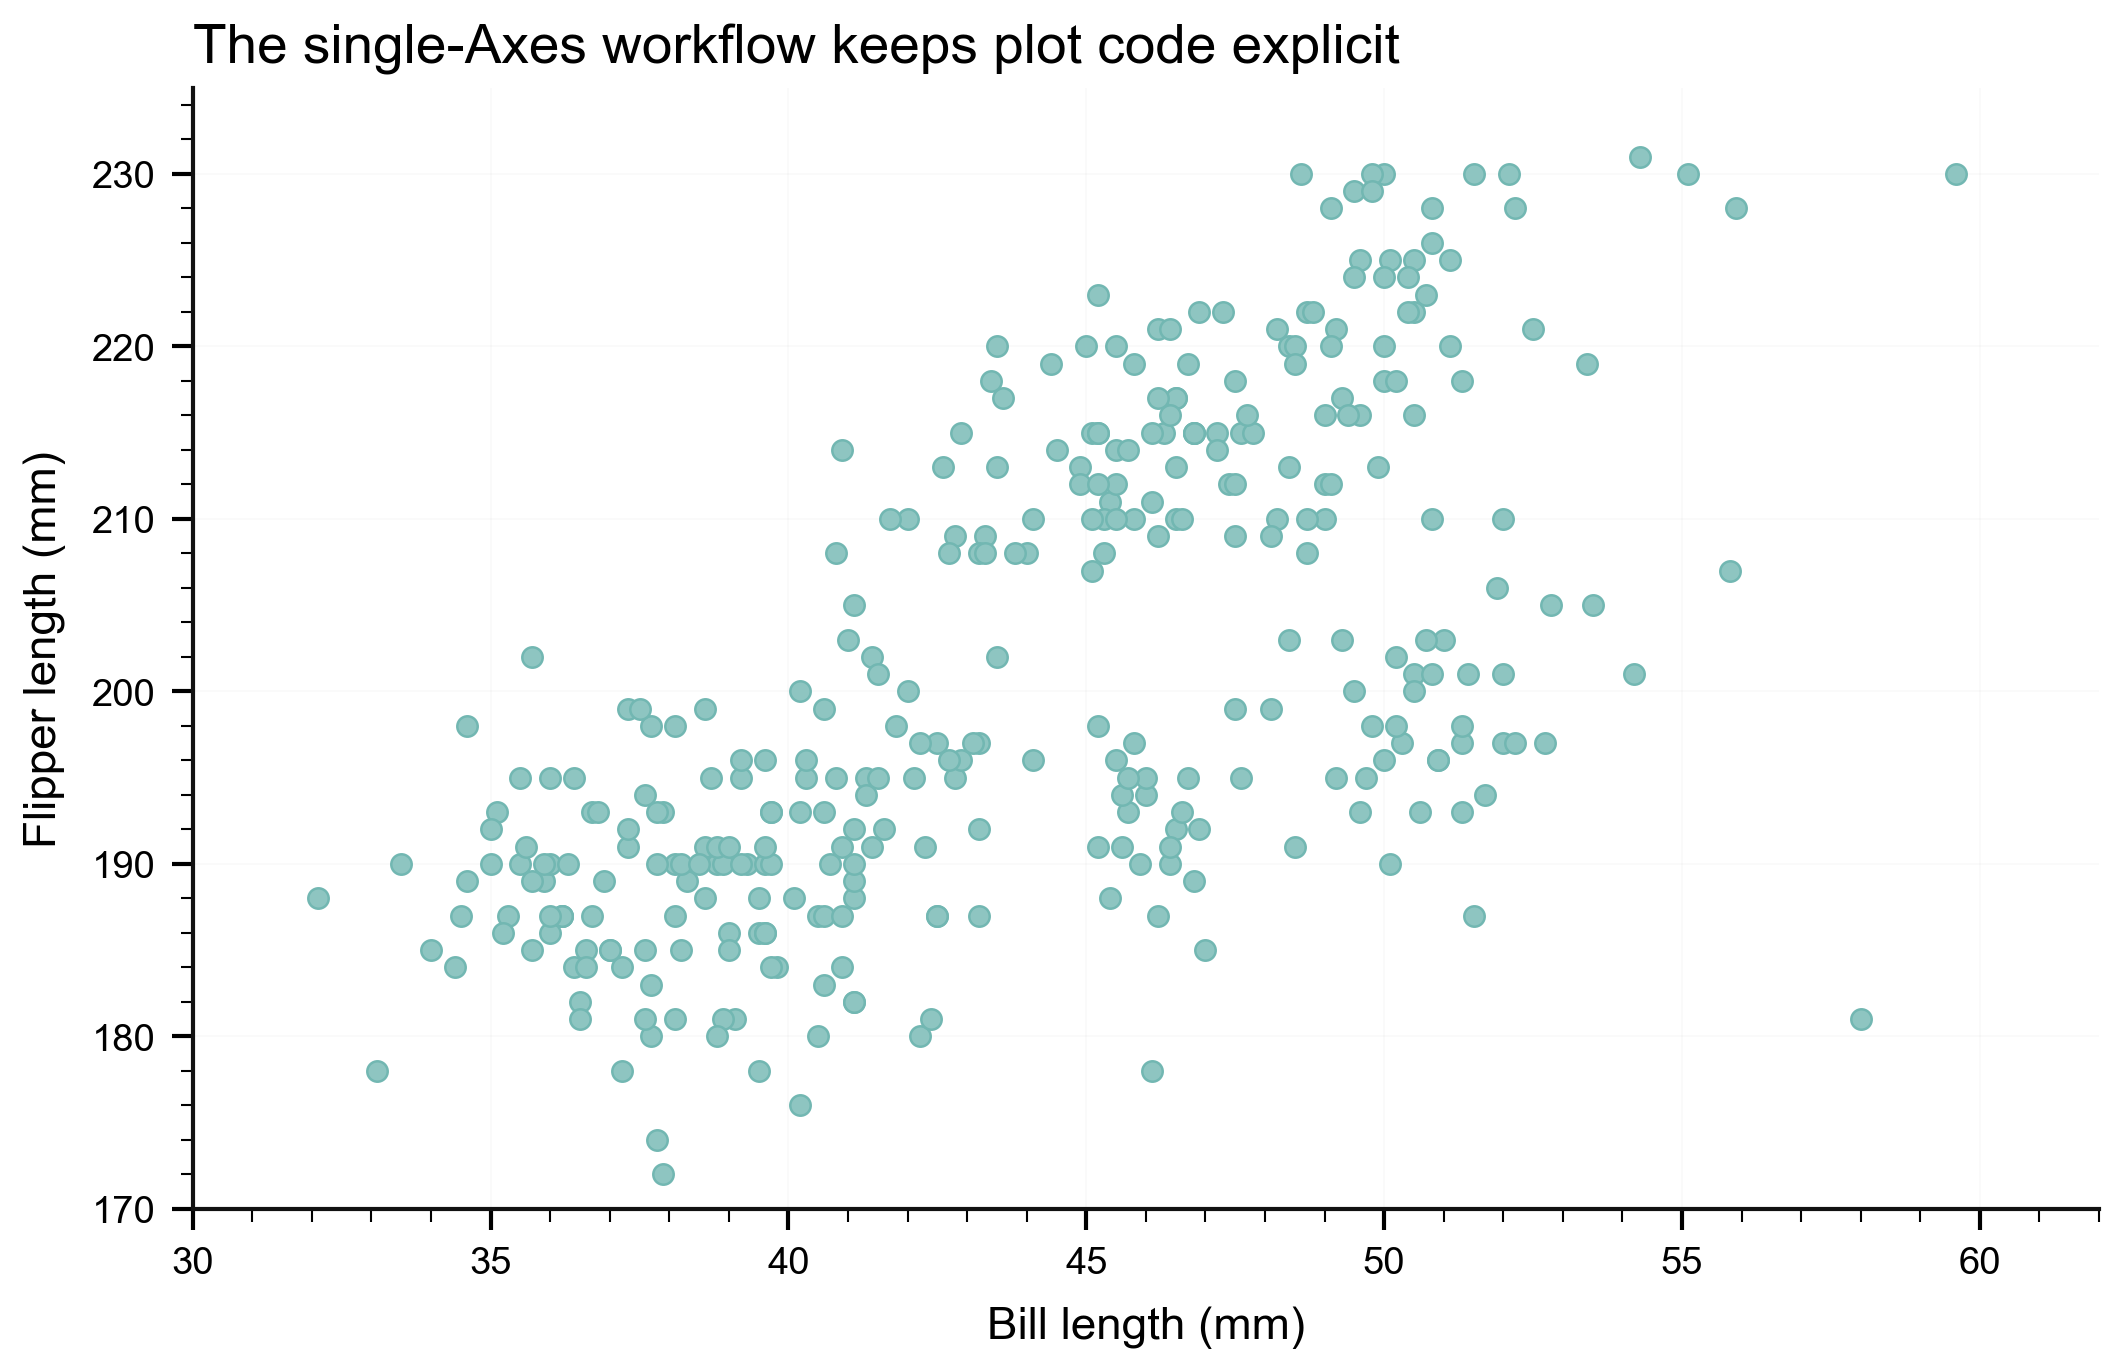

In [9]:
fig, ax = plt.subplots(figsize=FIG['standard'])
ax.scatter(
    pen['bill_length_mm'],
    pen['flipper_length_mm'],
    s=24,
    color=lighten_color(DV_PALETTE['teal'], 0.8),
    edgecolor=DV_PALETTE['teal'],
    linewidth=0.6,
)
ax.set(
    title='The single-Axes workflow keeps plot code explicit',
    xlabel='Bill length (mm)',
    ylabel='Flipper length (mm)',
)
ax.set_xlim(30, 62)
ax.set_ylim(170, 235)


**Why this pattern is so important**

The cell above is intentionally ordinary. That is exactly why it matters. Many real figures are just one axes with explicit labels and limits.

The more automatic a plotting wrapper becomes, the easier it is to forget this structure. Returning to the single-axes workflow keeps the logic clear:

- draw the marks
- label the panel
- set the scale you want
- decide whether the result is ready to show or save

### A small course helper: `style_axis(...)`

Up to this point, the notebook has used raw Matplotlib methods such as `ax.set_title(...)`, `ax.set_xlabel(...)`, and `ax.set_ylabel(...)` directly.

That was intentional. Students should first see that these are ordinary methods on the `Axes` object itself.

From this point onward, some of the repeated examples use `style_axis(...)`, a small helper defined in `dataviz_utils.py`.

It is **not** part of Matplotlib. It simply bundles a few repetitive axes-level tasks such as:

- setting titles and labels
- optionally turning the grid on or off
- applying the course's default axis-cleanup choices

The teaching rule is:

- first learn the raw Matplotlib methods
- then use the helper when repeated examples would otherwise become cluttered with boilerplate


## 5 — Regular subplot grids with `plt.subplots()`

As soon as one panel is not enough, the default next step is `plt.subplots()`.
This function creates one `Figure` and one or more `Axes` in a regular rectangular grid.

**What `plt.subplots()` returns**

The shape of the returned axes depends on the grid size:

| Call | `axs` type | Access |
|---|---|---|
| `plt.subplots()` | a single `Axes` | `ax` directly |
| `plt.subplots(1, 3)` | 1-D NumPy array of length 3 | `axs[i]` |
| `plt.subplots(2, 3)` | 2-D NumPy array `(2, 3)` | `axs[row, col]` |

This change in return type is a common source of errors.
The safest pattern for general use is `axs.flat`, which iterates over every axes regardless of grid shape.
Alternatively, pass `squeeze=False` to always get a 2-D array even for a `1 × N` grid.

**When to use regular grids**

- small multiples: the same chart type repeated for each group
- before/after comparisons
- multi-variable overviews

Irregular composition — one large panel alongside smaller ones, marginal axes, dedicated colorbar panels — belongs in the advanced subplotting notebook.


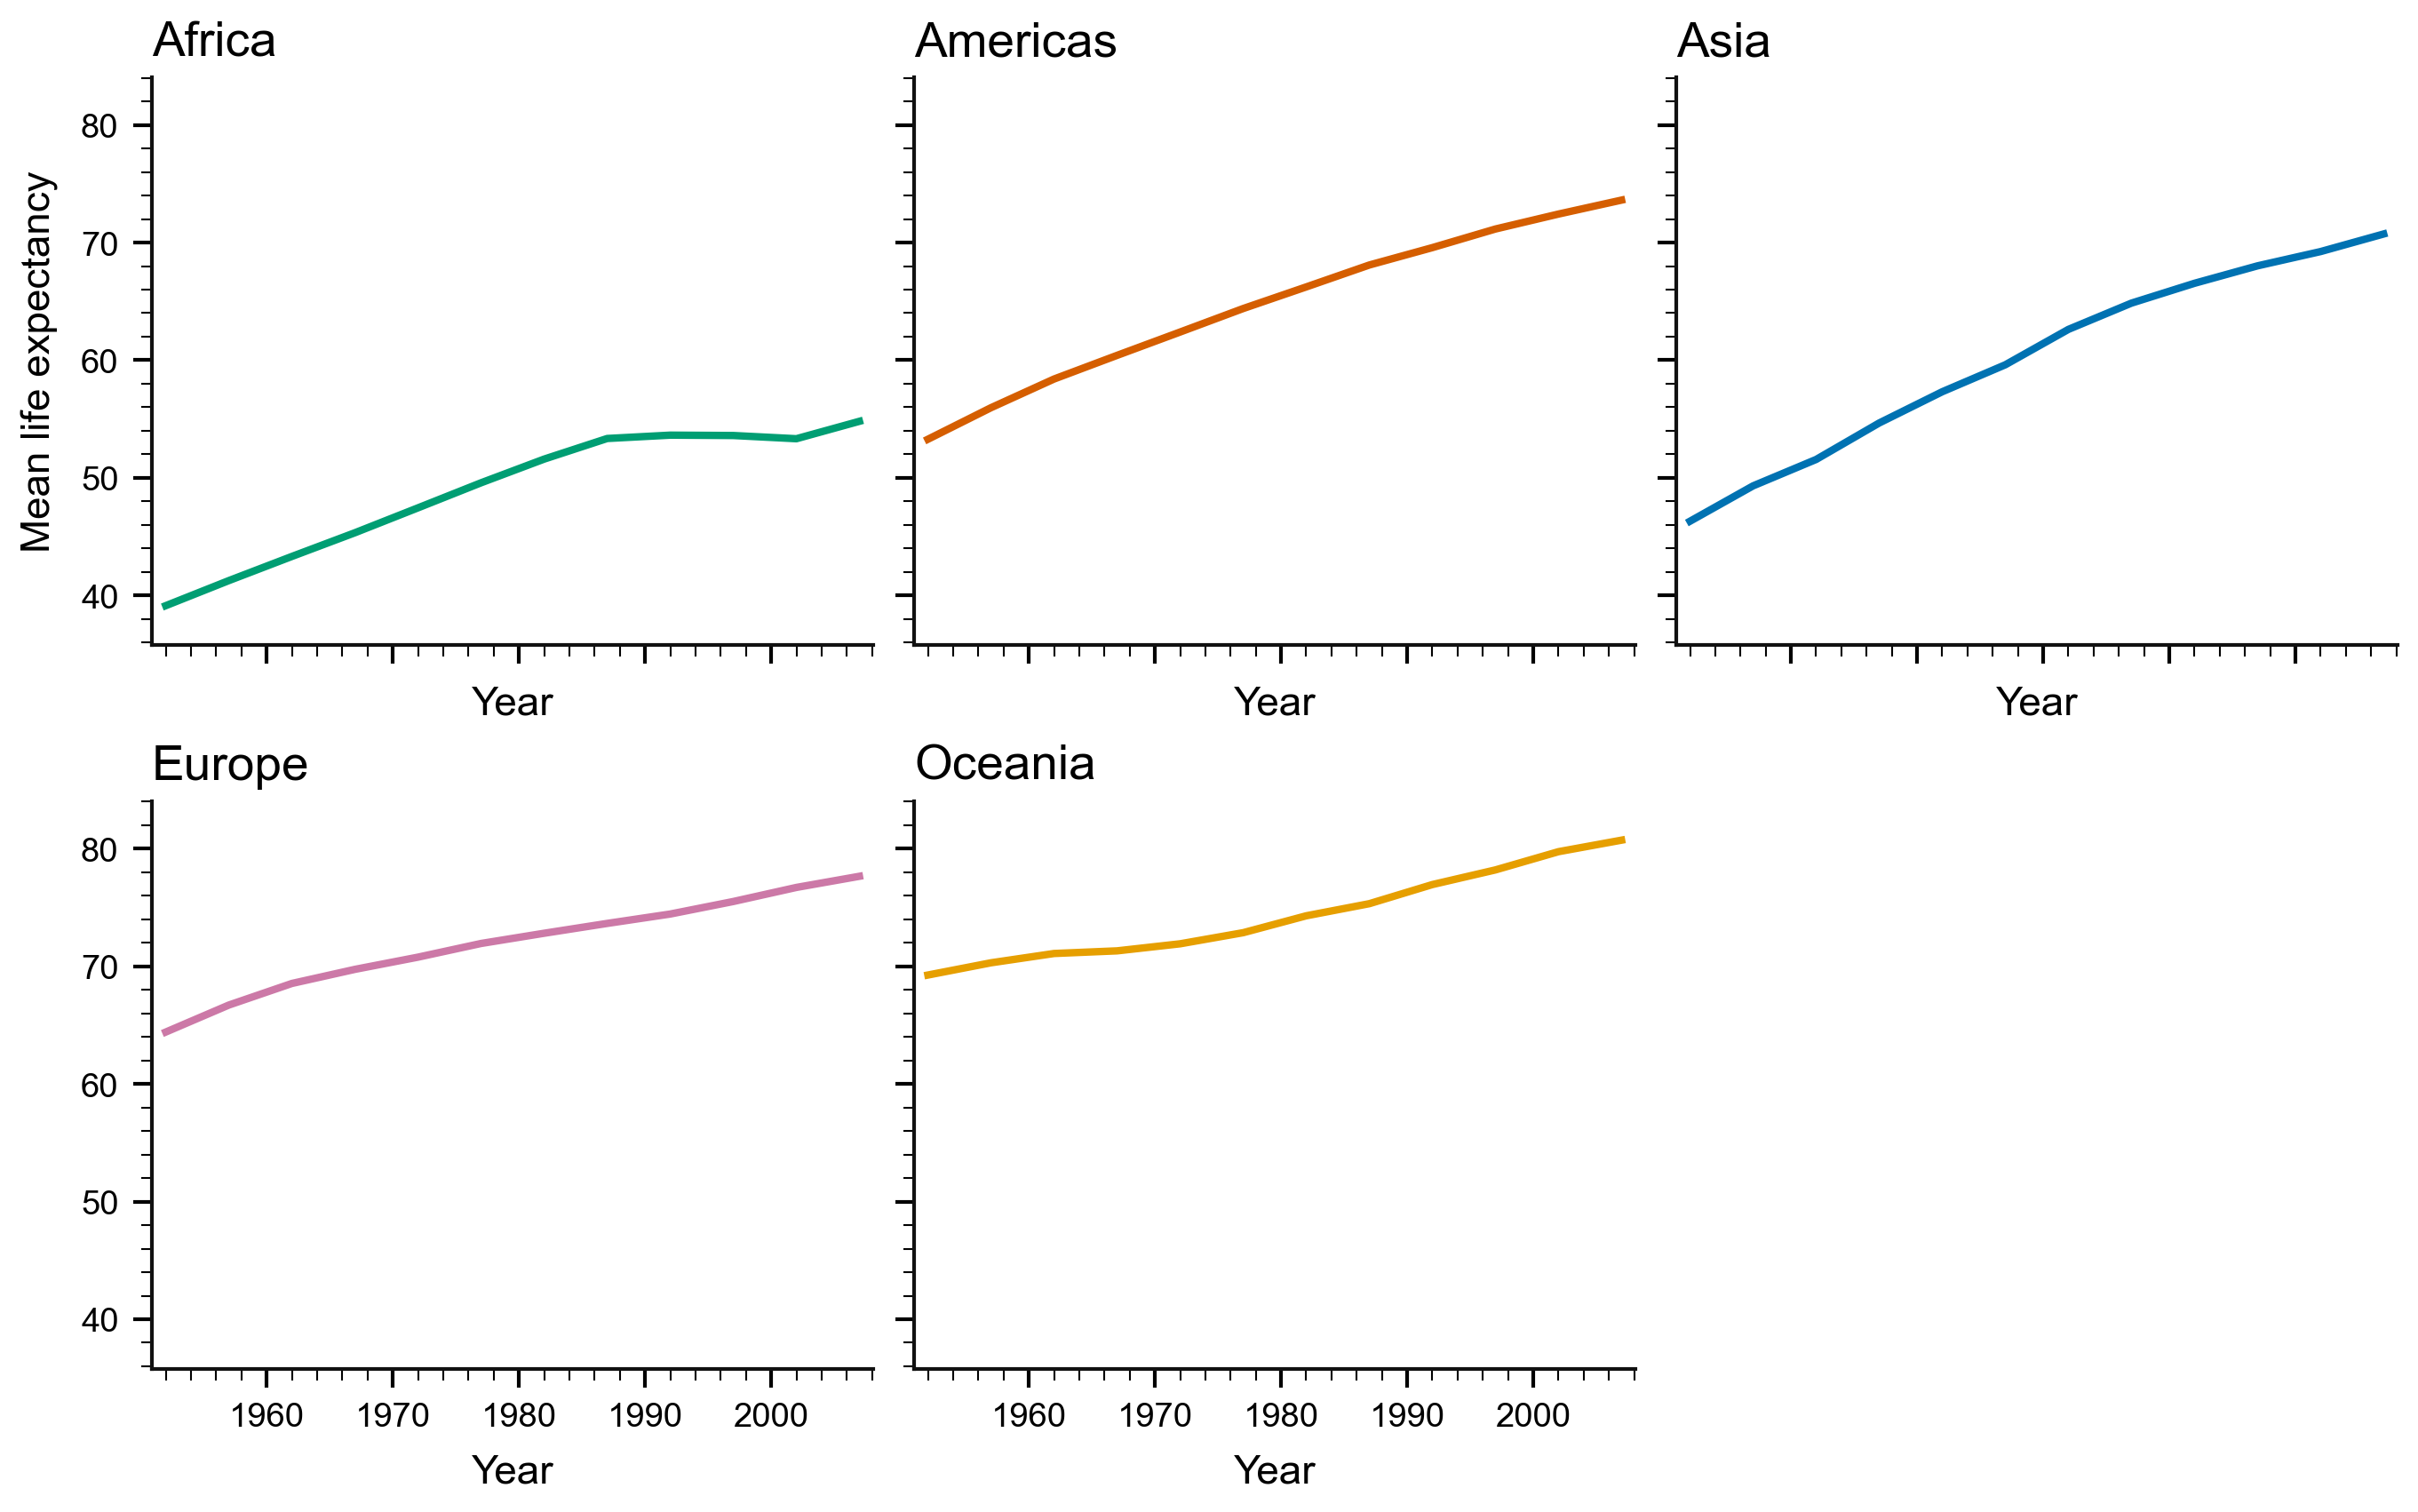

In [10]:
continents = list(CONTINENT_PALETTE.keys())
fig, axs = plt.subplots(2, 3, figsize=(FIG['wide'][0], 5.6), sharex=True, sharey=True)
for ax, continent in zip(axs.flat, continents + [None]):
    if continent is None:
        ax.axis('off')
        continue
    grp = continent_year[continent_year['continent'] == continent]
    ax.plot(grp['year'], grp['lifeExp'], color=CONTINENT_PALETTE[continent])
    style_axis(ax, title=continent, xlabel='Year', ylabel='Mean life expectancy' if continent == 'Africa' else '', grid=False)


**What to notice in this first grid example**

The grid has six positions but only five continents. We therefore turn the extra axes off. That small detail is useful because it shows that `plt.subplots()` returns real axes objects for every slot in the grid. If one slot is not needed, you decide what to do with it.

The code also shows a common pattern: iterate over `axs.flat`. When a grid is regular, treating the axes as a collection keeps the code compact and readable.

### Shared axes and iteration

When multiple panels show the same variables, repeating tick labels and scale ranges in every panel adds clutter without adding meaning.

`sharex=True` links all panels to the same x-scale.
`sharey=True` links all panels to the same y-scale.

Two benefits:

1. the comparison is **honest** — the same position corresponds to the same value in every panel
2. the figure is **quieter** — Matplotlib suppresses redundant tick labels on interior panels automatically

This is especially useful for small multiples, where the key question is comparative:
*how do these groups differ under the same measurement system?*

> **Tip for iteration:** use `axs.flat` to iterate over a 2-D axes array as if it were a 1-D list.
> Or pass `squeeze=False` to `plt.subplots()` so you always get a 2-D array:
> ```python
> fig, axs = plt.subplots(1, 3, squeeze=False)  # axs has shape (1, 3)
> for ax in axs.flat: ...
> ```


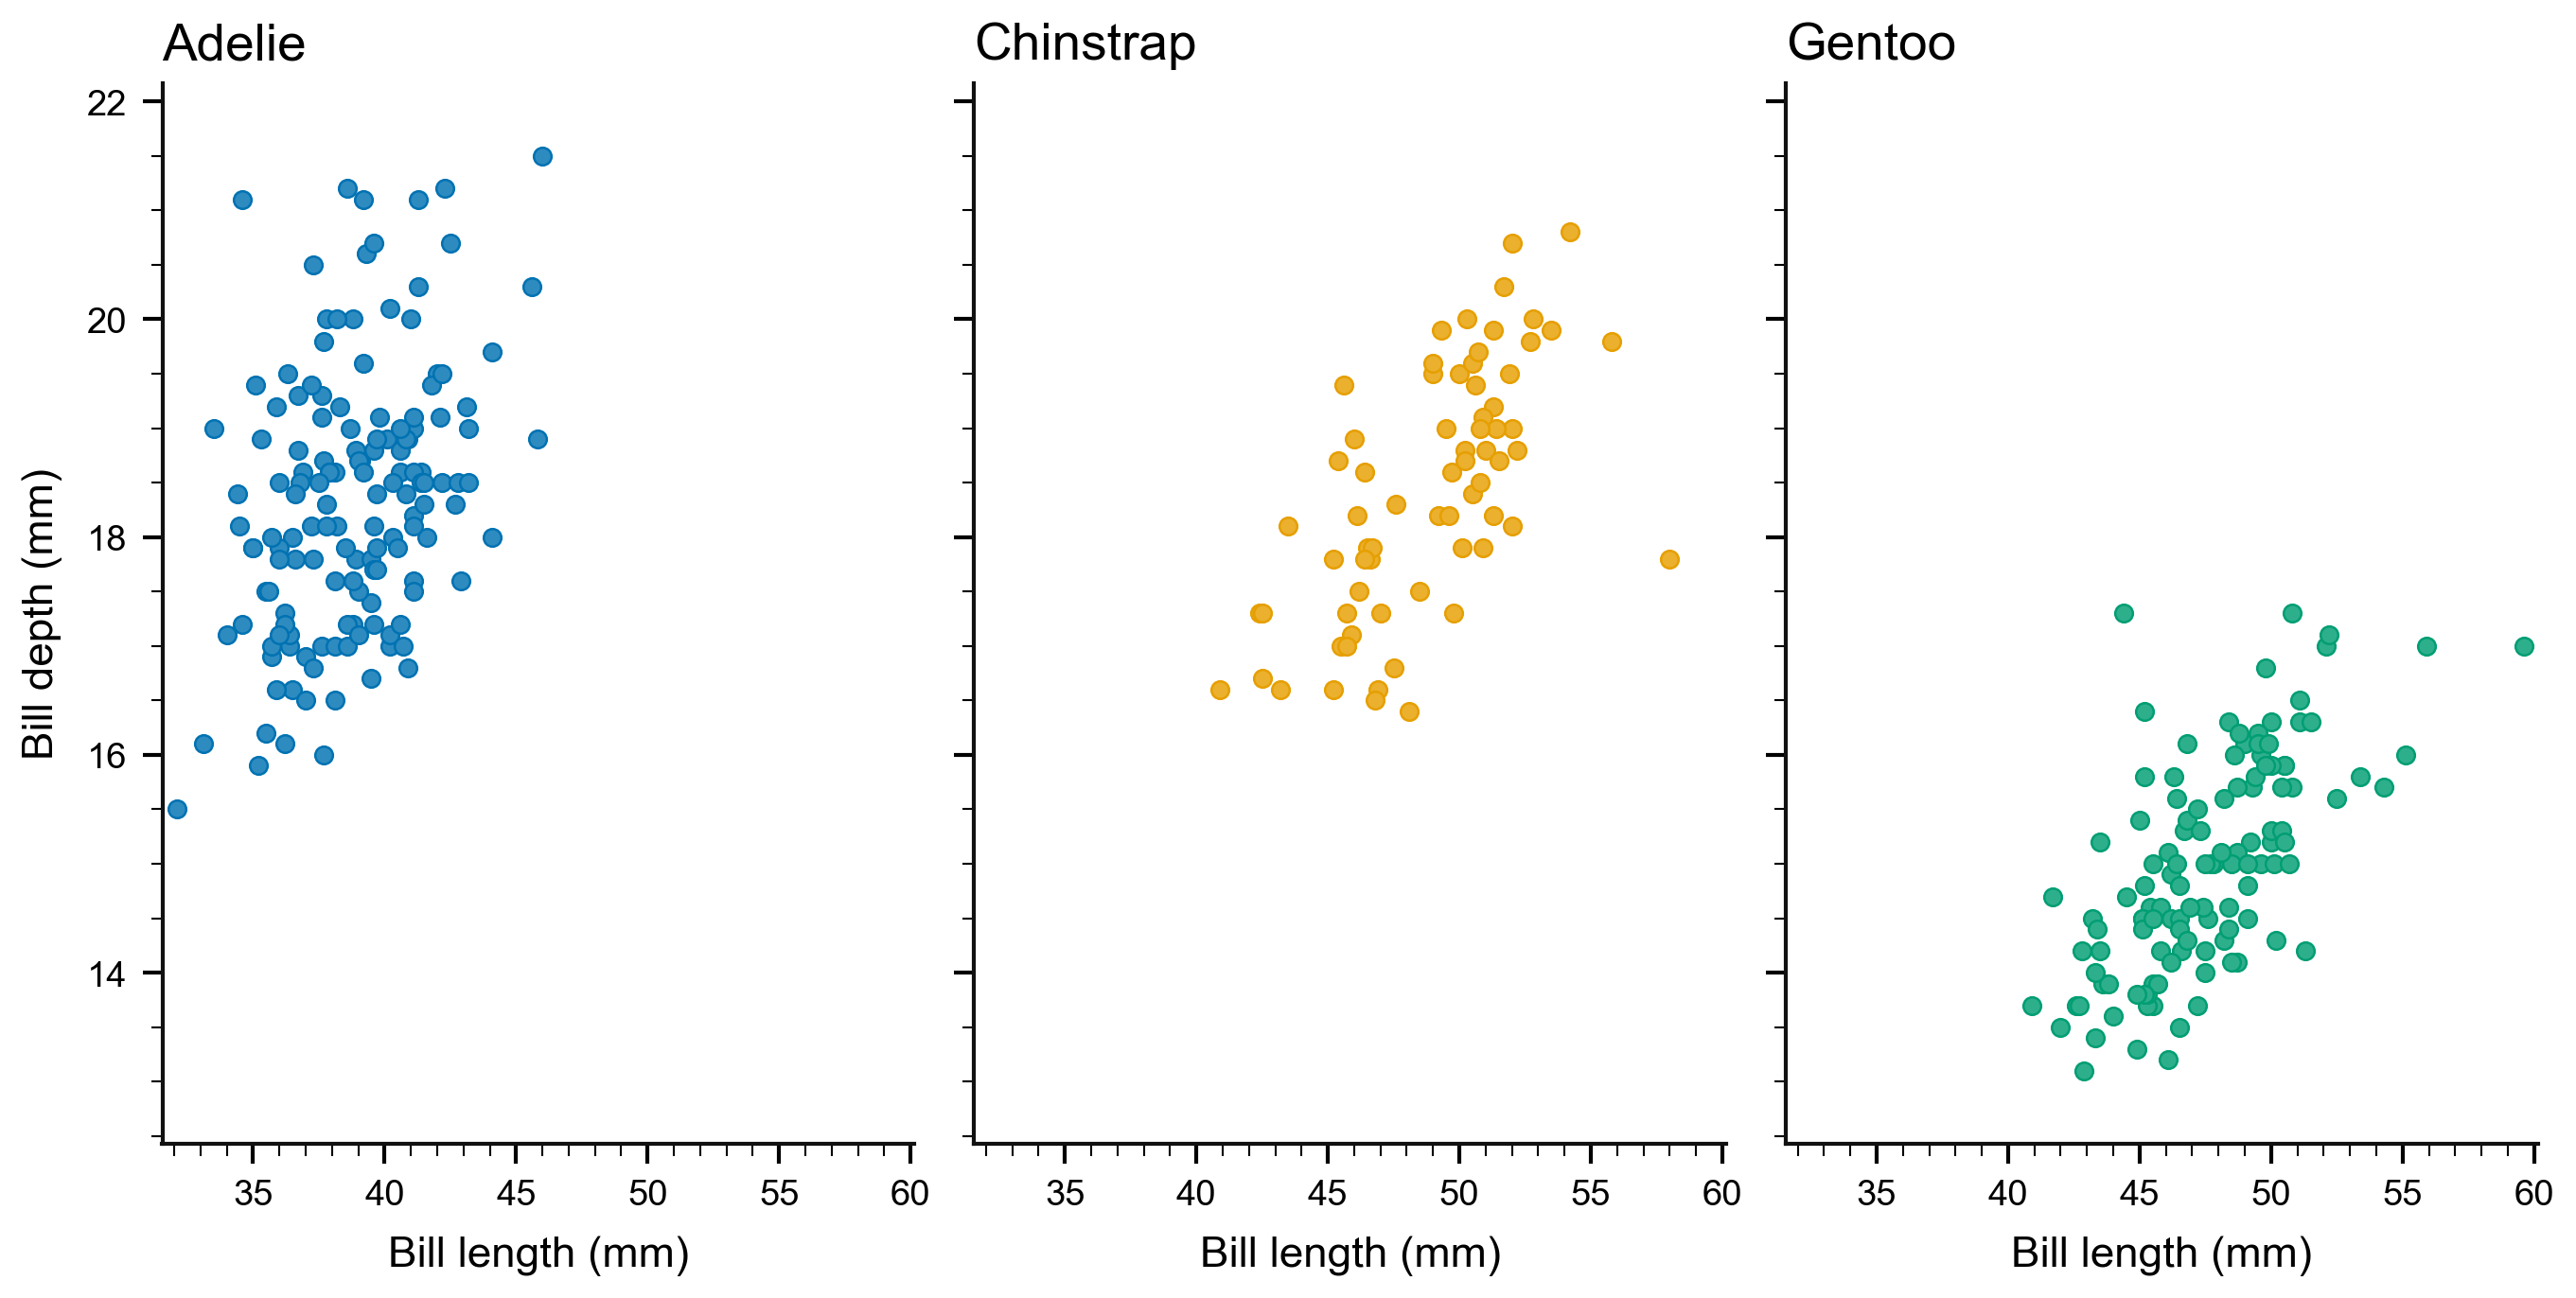

In [11]:
fig, axs = plt.subplots(1, 3, figsize=FIG['wide'], sharex=True, sharey=True)
for ax, species, color in zip(axs, ['Adelie', 'Chinstrap', 'Gentoo'], CATEGORICAL_PALETTE[:3]):
    grp = pen[pen['species'] == species]
    ax.scatter(
        grp['bill_length_mm'],
        grp['bill_depth_mm'],
        s=20,
        color=lighten_color(color, 0.82),
        edgecolor=color,
        linewidth=0.6,
    )
    style_axis(ax, title=species, xlabel='Bill length (mm)', ylabel='Bill depth (mm)' if species == 'Adelie' else '', grid=False)


**Why shared axes are usually the right choice here**

If each species panel had its own independent limits, the panels might look larger or smaller simply because the scales changed. Shared axes prevent that problem. The visual comparison becomes more honest because the same positions correspond to the same numeric values in every panel.

## 6 — Layout engines at a high level

Once a figure has more than one panel, spacing becomes a real concern.
Titles, axis labels, tick labels, and legends can collide if the layout is too tight.

A **layout engine** is Matplotlib's logic for deciding how much space to reserve around and between panels.

### The course default

`setup_matplotlib()` sets `figure.layout = "constrained"` globally (Matplotlib 3.7+),
so **every figure you create already uses constrained layout by default**.
You do not need to pass `layout='constrained'` explicitly for most work.

The explicit form `plt.subplots(..., layout='constrained')` is still worth knowing —
it makes the choice visible in the code, and you will need it when overriding
the global default locally.

### Other options you will encounter

| Value | Behaviour |
|---|---|
| `layout='constrained'` (default) | automatic, safe for most figures |
| `layout='tight'` | older engine, similar goal, less reliable |
| `layout=None` | disables the engine — needed when you want manual `hspace`/`wspace` |
| `layout='compressed'` | like constrained but compresses space further, useful for dense matrix grids |

You will also see older code online that calls `plt.tight_layout()` or `fig.tight_layout()`.
That is a legacy spacing call — it works, but `layout='constrained'` at figure-creation time is the cleaner modern approach.

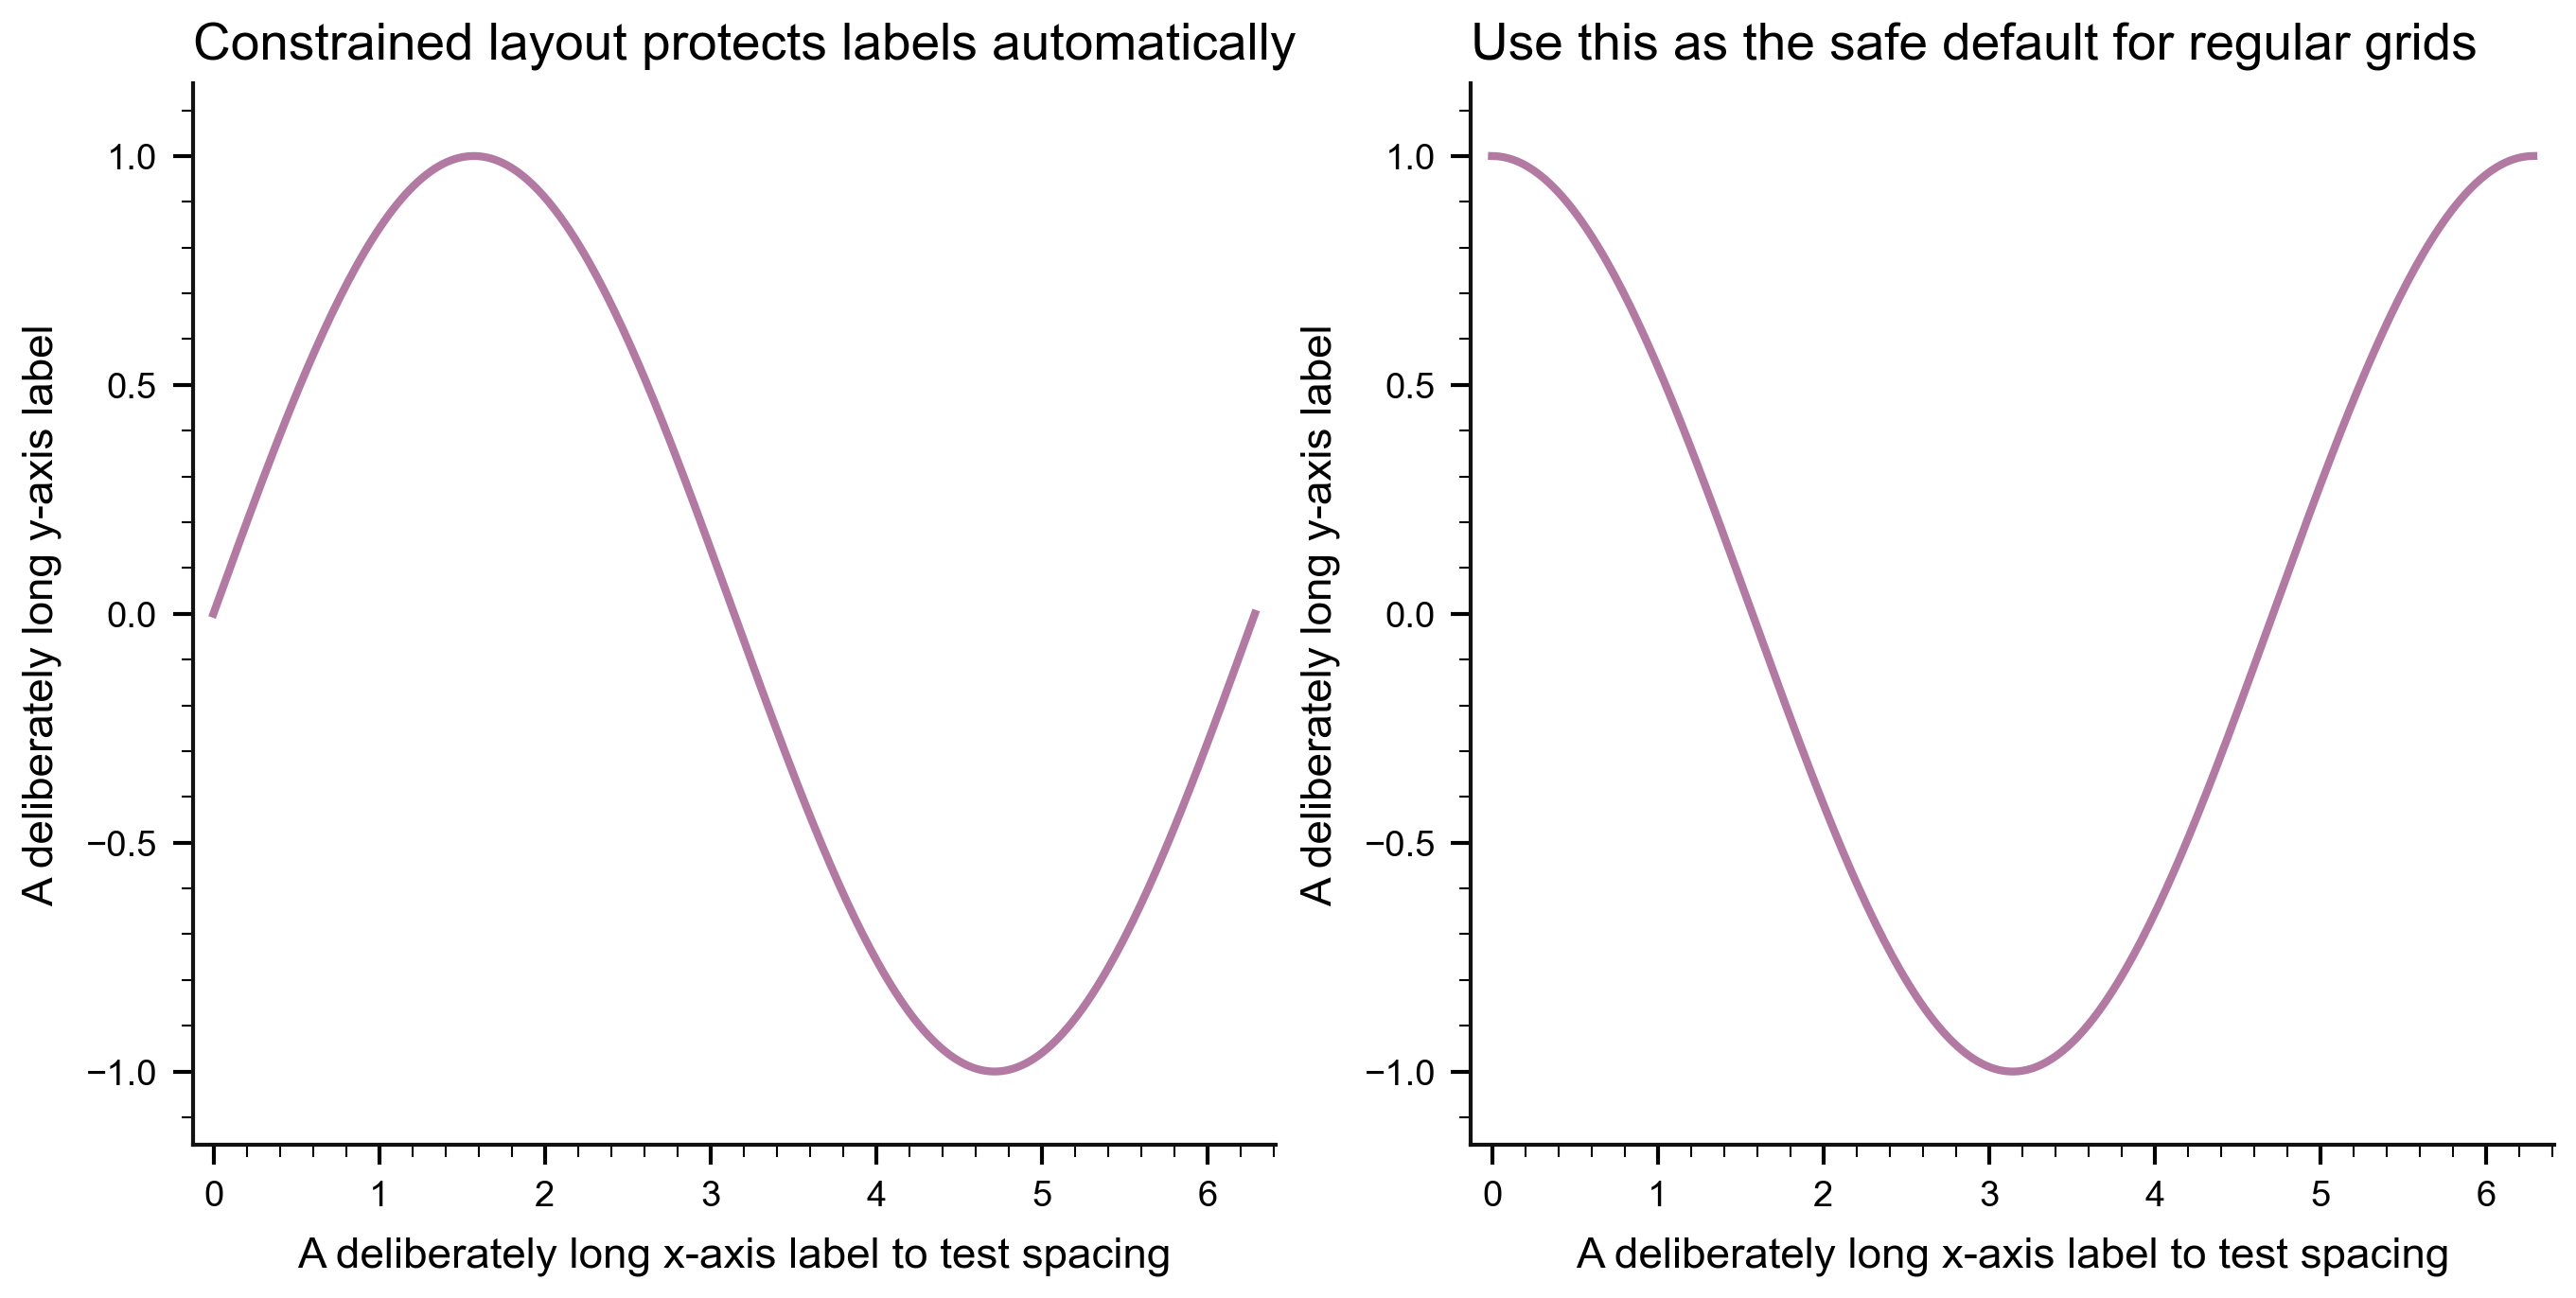

In [12]:
fig, axs = plt.subplots(1, 2, figsize=FIG['wide'], layout='constrained')
for ax, phase, title in zip(
    axs,
    [0, np.pi / 2],
    ['Constrained layout protects labels automatically', 'Use this as the safe default for regular grids'],
):
    ax.plot(x, np.sin(x + phase), color=DV_PALETTE['purple'])
    style_axis(
        ax,
        title=title,
        xlabel='A deliberately long x-axis label to test spacing',
        ylabel='A deliberately long y-axis label',
        grid=False,
    )


**What this section is really teaching**

The main point is not to memorize layout options. It is to learn where to start.

Students often try to fix overlapping labels by immediately using manual spacing commands. That usually makes a simple figure harder to maintain. The better default is:

1. create a sensible figure size
2. use `layout='constrained'`
3. move to advanced composition tools only when the figure is genuinely irregular

That advanced step belongs in notebook 4.

## 7 — Saving figures

Displaying a figure in a notebook is only part of the workflow.
A figure usually needs to be exported for slides, reports, or papers.

### Format choice

| Format | Type | Best for |
|---|---|---|
| PNG | raster (pixels) | embedding in documents, web, quick sharing |
| PDF | vector (geometry) | printing, zooming, LaTeX inclusion |
| SVG | vector | web, further editing in Inkscape/Illustrator |

For publication figures, PDF is usually the right default.
For figures that will be pasted into a slide deck or web page, PNG is more convenient.

### Key parameters for `fig.savefig()`

- **`dpi`** — raster resolution (only affects PNG, not PDF/SVG). Use `SAVEFIG_DPI` from the course utils (360 dpi).
- **`bbox_inches='tight'`** — trims extra whitespace around the figure. `setup_matplotlib()` already sets this as the global default via `savefig.bbox`, so you usually do not need to pass it explicitly.
- **`facecolor`** — background color of the saved file. Also set globally by `setup_matplotlib()`.

### Saving without re-showing

After `fig.savefig(...)`, close the figure with `plt.close(fig)` to free memory — especially important when saving many figures in a loop.


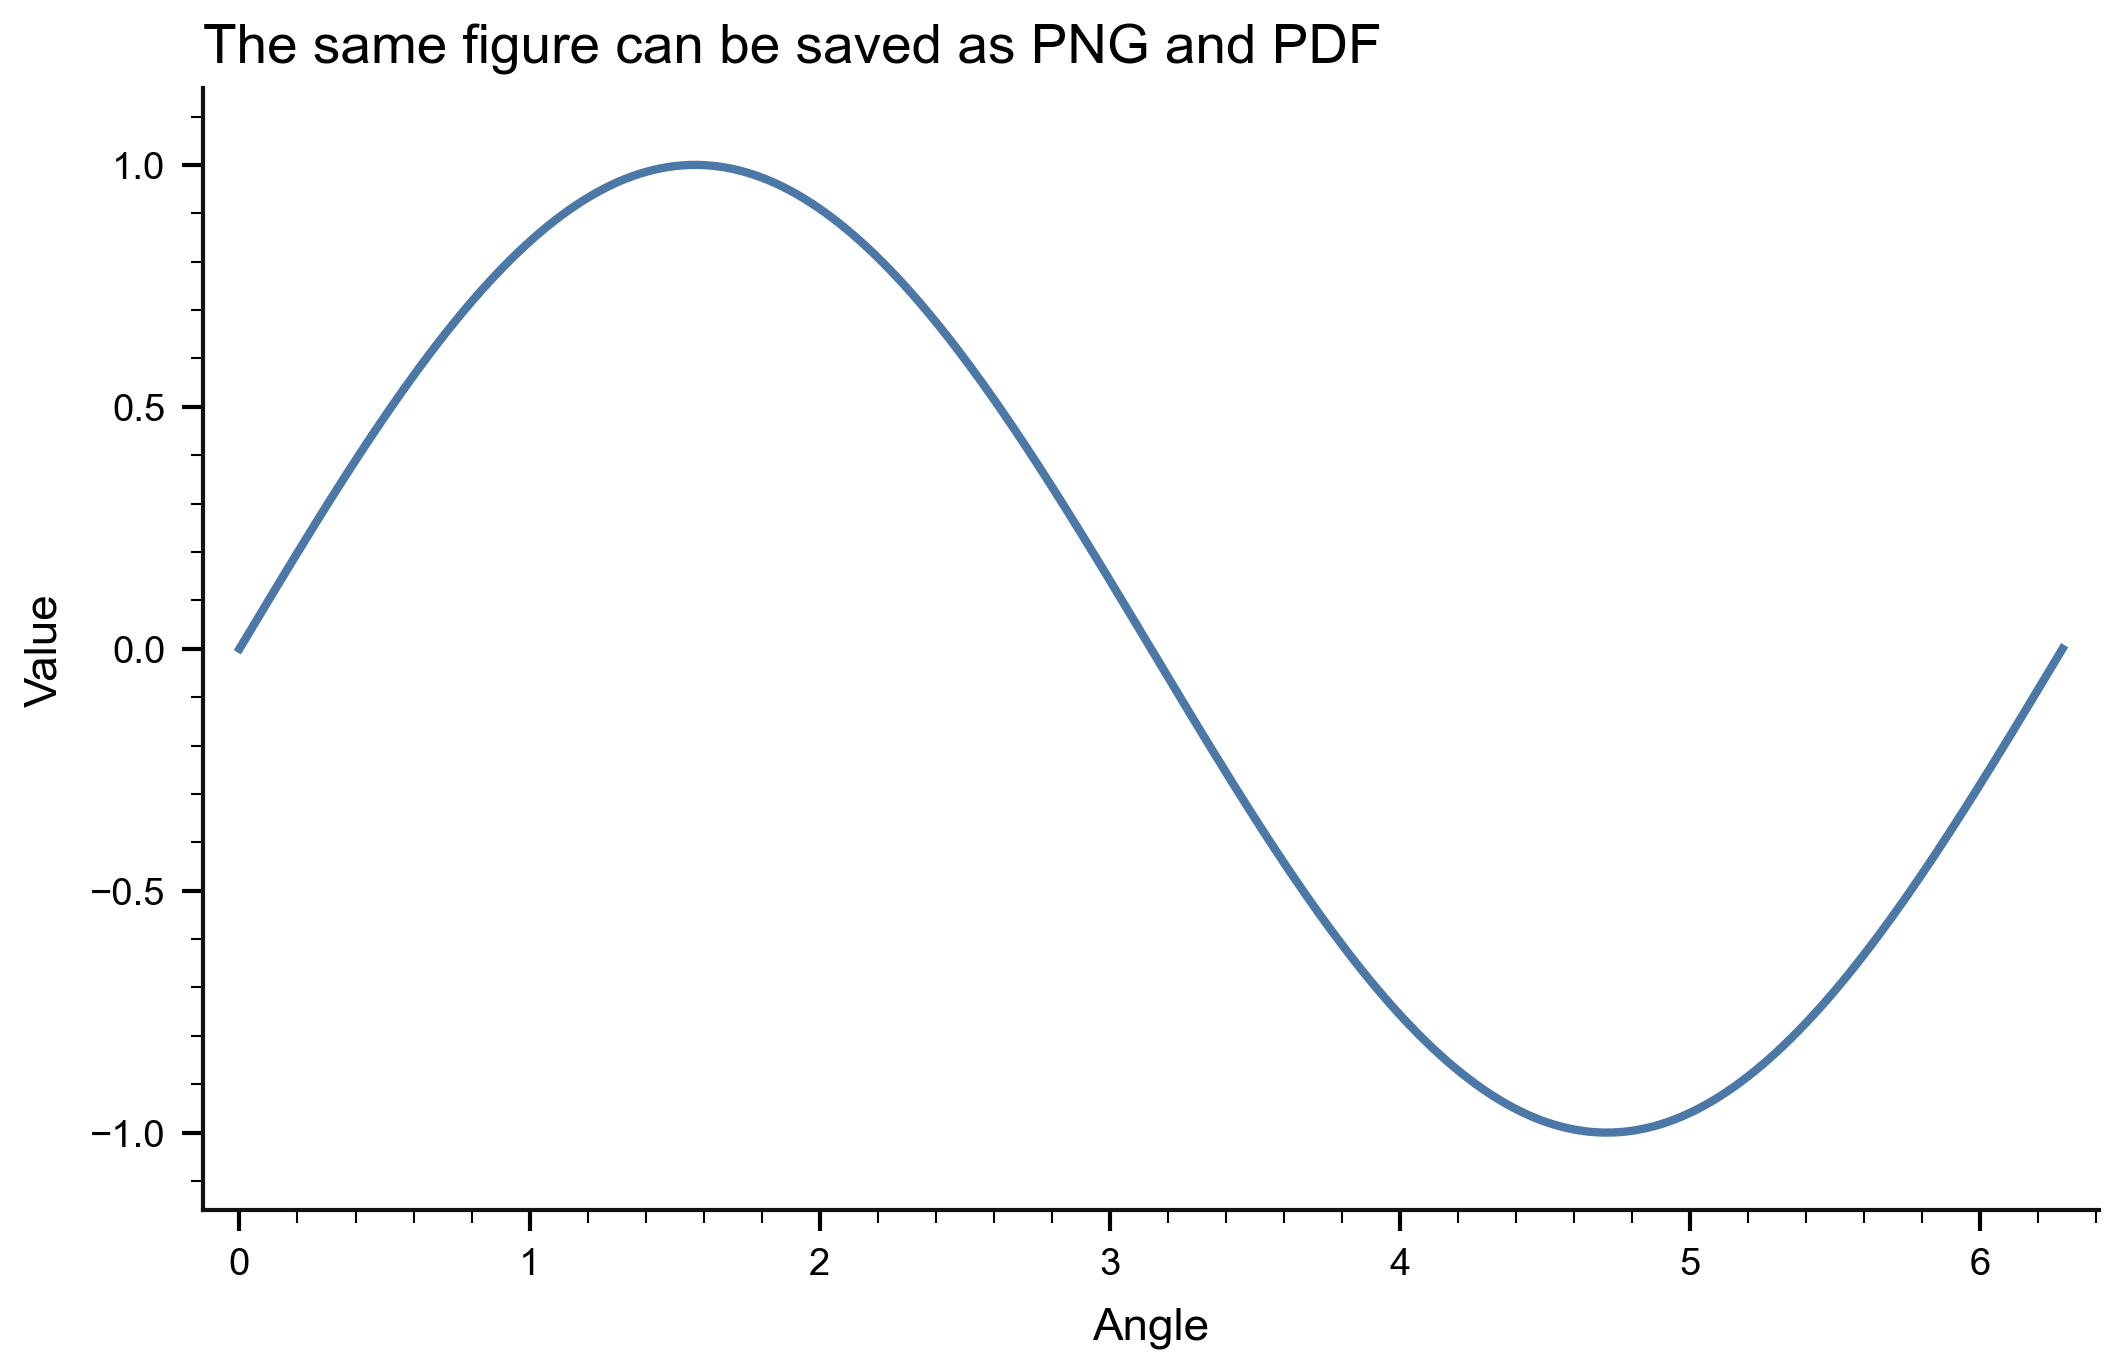

PNG: /tmp/matplotlib-intro/sine.png  (131 kB)
PDF: /tmp/matplotlib-intro/sine.pdf  (15 kB)
Note the size difference: PDF stores geometry, PNG stores pixels.


In [13]:
from pathlib import Path

out_dir = Path('/tmp/matplotlib-intro')
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=FIG['standard'])
ax.plot(x, np.sin(x), color=DV_PALETTE['blue'])
style_axis(ax, title='The same figure can be saved as PNG and PDF', xlabel='Angle', ylabel='Value', grid=False)

png_path = out_dir / 'sine.png'
pdf_path = out_dir / 'sine.pdf'

# SAVEFIG_DPI = 360 (from dataviz_utils) — only affects raster formats like PNG
# bbox_inches='tight' is already the global default from setup_matplotlib()
fig.savefig(png_path, dpi=SAVEFIG_DPI)
fig.savefig(pdf_path)
plt.show()
plt.close(fig)   # free memory — good habit, especially in loops

print(f'PNG: {png_path}  ({png_path.stat().st_size // 1024} kB)')
print(f'PDF: {pdf_path}  ({pdf_path.stat().st_size // 1024} kB)')
print('Note the size difference: PDF stores geometry, PNG stores pixels.')


**How to read the export example**

The same figure can be written to more than one target format. The plotting code does not need to change; only the save target and a few export settings change.

This is another reason the figure/object model matters. The figure is not only something you "show" on screen. It is also an object that you can export deliberately.

## Takeaway

By this point, the main structural ideas of Matplotlib should be much clearer:

- Matplotlib is a hierarchy of objects, not a single plotting command.
- `Figure`, `Axes`, `Axis`, and `Artist` have different responsibilities.
- `pyplot` is convenient because it manages current state for you, but the object-oriented workflow is safer once a figure has more than one panel.
- A single `Axes` is the basic plotting unit.
- `plt.subplots()` is the default tool for regular grids.
- Figure size, DPI, layout, and saving are figure-level decisions that should be made deliberately.

That is the foundation we need before moving on to appearance and chart families.

## Common mistakes

- **Confusing `Axes` with `Axis`.** `Axes` is the whole panel; `Axis` is one scale (x or y) inside it.
- **Mixing `plt.*` and `ax.*` calls** without tracking which axes is currently active.
- **Raising DPI when the real problem is figure size.** DPI sharpens raster output; it does not make a cramped layout less cramped.
- **Independent limits in small multiples.** If your goal is comparison, use `sharex=True` / `sharey=True`.
- **Reaching for advanced layout tools too early.** Try `plt.subplots()` with `layout='constrained'` first.
- **Not calling `plt.close(fig)` after saving in loops.** Matplotlib will warn once more than 20 figures are open and silently leak memory.
- **Calling `plt.tight_layout()` after `layout='constrained'`.** The two engines conflict — pick one.


## Exercise

Create a short figure-building script that proves you understand the workflow in this notebook.

1. Create a `1 × 2` figure with `plt.subplots()`.
2. Plot `sin(x)` on the left and `cos(x)` on the right.
3. Give the two panels a shared y-axis.
4. Save the result once as PNG and once as PDF.
5. Print the type of the `Figure` object and the type of one `Axes` object.

Before you start typing, ask yourself three questions:

- which part of the code creates the figure?
- which part of the code targets each axes explicitly?
- which part of the code is about export rather than drawing?

In [14]:
# Your answer here
# Suggested scaffold:
# 1. create x values
# 2. create fig, axs with plt.subplots(...)
# 3. plot on axs[0] and axs[1]
# 4. set labels/titles
# 5. save as PNG and PDF
# 6. print the object types